# Classifying the Cosmos: Identifying Stars, Galaxies and Quasars from Spectral Data
#### Tar Ivett-Dora - grupa 30235

> This project investigates whether the light profile of a celestial object, measured across ultraviolet, green, red, and infrared filters. These can reliably classify it as a star, galaxy, or quasar, using photometric and spectral data from the Sloan Digital Sky Survey (SDSS DR17).


---

## 1. Setup & imports

Loading all necessary libraries for data manipulation and visualization.

In [1]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Utilities
import warnings
warnings.filterwarnings('ignore')

# the next 5 lines define the default font sizes for plots
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

The following function will help us to save the figures as high resolution PNGs.

In [2]:
from pathlib import Path

IMAGES_PATH = Path() / "images"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---

## 2. Loading the data

Source: https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17

We are working with a single, self-contained dataset from the Sloan Digital Sky Survey (SDSS DR17). Each row represents one observed celestial object, and our goal is to classify it as a **Star**, **Galaxy**, or **Quasar** based on its light measurements.

Everything we need, both the input features and the label we want to predict, is already in one CSV file. This lets us focus almost entirely on understanding the data and building the model. 

In [3]:
df = pd.read_csv('data/star_classification.csv')
print(f'Shape: {df.shape}\n')
print("First 5 rows of the dataset:")
df.head()

Shape: (100000, 18)

First 5 rows of the dataset:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


---

## 3. Data Overview

Getting a first look at the structure, data types, and basic statistics of the dataset before doing any cleaning or analysis.

### 3.1 Structure & Data Types

Checking the column names, types, and whether any values are missing across the dataset.

In [4]:
print("The dataset:")
df

The dataset:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

In [6]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [7]:
print("Last 5 rows of the dataset:")
df.tail()

Last 5 rows of the dataset:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470
99999,1.237661e+18,196.896053,49.464643,22.62171,21.79745,20.60115,20.00959,19.28075,3650,301,4,60,8.343152e+18,GALAXY,0.542944,7410,57104,851


In [8]:
print("Existing columns in the dataset:")
df.columns

Existing columns in the dataset:


Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

### 3.2 Basic Statistics

A summary of the distribution of each numeric column. It is useful for spotting extreme values or unexpected ranges.

In [9]:
print("\nDescriptive statistics:")
df.describe()


Descriptive statistics:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


Looking at this we can see that for the u, g and z attributes there is something going on because the mean is around 20 but the min value is -9999, so those values may signal a problem or some irregularity. We will be looking into that in the next parts.

Examining the class column which represents the classification we want to do to see how many different values there are and how many rows there are for each type.

In [10]:
df["class"].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

We can see that there are no strange values, only the 3 classes we want to classify our celestial object into (GALAXY, STAR, QUASAR). We can also see that there are far more galaxies than stars or quasars.

### 3.3 Missing Values

Checking for missing data across all columns.

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_%


As we can see, all of the cells have values. This means that we won't have to eliminate rows.

---
## 4. Data Cleaning

Removing columns that carry no useful information for classification, and encoding the target variable into a numeric format the model can work with.

### 4.1 Drop Identifier Columns

Several columns are unique identifiers (IDs, observation numbers, catalog references) that have no predictive value and would only confuse the model if left in.

Our dataset has multiple columns, with these semnifications:

1. obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
2. alpha = Right Ascension angle (at J2000 epoch)
3. delta = Declination angle (at J2000 epoch)
4. u = Ultraviolet filter in the photometric system
5. g = Green filter in the photometric system
6. r = Red filter in the photometric system
7. i = Near Infrared filter in the photometric system
8. z = Infrared filter in the photometric system
9. run_ID = Run Number used to identify the specific scan
10. rereun_ID = Rerun Number to specify how the image was processed
11. cam_col = Camera column to identify the scanline within the run
12. field_ID = Field number to identify each field
13. spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
14. class = object class (galaxy, star or quasar object)
15. redshift = redshift value based on the increase in wavelength
16. plate = plate ID, identifies each plate in SDSS
17. MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
18. fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

Based on these we will be dropping any unnecessary columns. 

In [12]:
print("All columns in the dataset:")
df.columns

All columns in the dataset:


Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='str')

In [13]:
# these are all the columns which represent ids or some unique values
id_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

df = df.drop(columns=[c for c in id_cols if c in df.columns])
print(f'Remaining columns: {df.columns.tolist()}')

Remaining columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


Taking a quick look at the new, cleaned Data Structure

In [14]:
print("First 5 rows of the new dataset:")
df.head()

First 5 rows of the new dataset:


,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   alpha     100000 non-null  float64
 1   delta     100000 non-null  float64
 2   u         100000 non-null  float64
 3   g         100000 non-null  float64
 4   r         100000 non-null  float64
 5   i         100000 non-null  float64
 6   z         100000 non-null  float64
 7   class     100000 non-null  str    
 8   redshift  100000 non-null  float64
dtypes: float64(8), str(1)
memory usage: 6.9 MB


In [16]:
print("Description of the new, cleaned dataset:")
df.describe()

Description of the new, cleaned dataset:


,alpha,delta,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,0.576661
std,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,0.730707
min,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,-0.009971
25%,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,0.054517
50%,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,0.424173
75%,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,0.704154
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


### 4.2 Encode the Target Variable

The `class` column contains text labels (STAR, GALAXY, QSO). We convert these to numbers so that scikit-learn models can work with them, while keeping a reference mapping for display purposes later.

Preprocessing the Strings into integers, but our only String column is the `class` column.

In [17]:
label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])

# Reference mapping
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Class mapping:', class_mapping)

Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


---
## 5. Exploratory Data Analysis (EDA)

Understanding the patterns, distributions, and relationships in the data before training any model. This is an important step for understanding the problem.

### 5.1 Overview

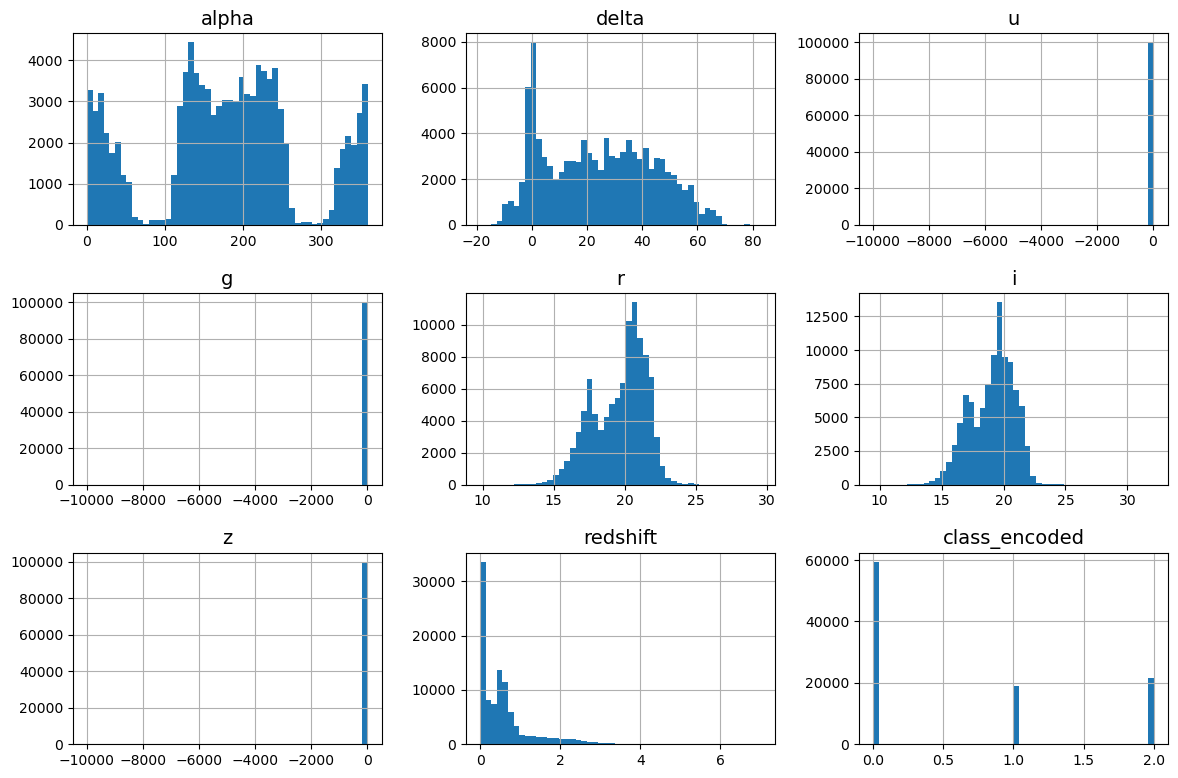

In [18]:
df.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")
plt.show()

Looking at the histograms, a few things stand out immediately.

The **photometric filters u, g, and z** show a very unusual distribution. Almost all 
values are piled up at 0, with a long tail of extreme negative values reaching down to 
-9000 or lower. This is not a real physical measurement but rather a known quirk of the 
SDSS dataset, where missing or invalid filter readings are filled with a large negative 
sentinel value (typically -9999). These rows will need to be handled before training, 
either by replacing them with NaN, or by filtering them out entirely. This is confirmed by what we observed in earlier stages.

The **r and i filters** look much more normal, they follow a roughly bell-shaped 
distribution centered around magnitudes 20–22, which is consistent with what we would 
expect from real astronomical observations.

The **redshift** distribution is heavily right-skewed, with most objects clustered near 
zero and a long tail extending to values above 4. This reflects the mix of object types 
in the dataset: stars have redshifts very close to 0, galaxies sit in a low-to-mid range, 
and quasars can reach much higher values, making redshift a very powerful distinguishing 
feature between classes.

The **alpha and delta** columns represent the sky coordinates (right ascension and 
declination) of each object. Their distributions reflect the survey coverage pattern of 
the SDSS telescope rather than any physical property of the objects, so they should 
likely be dropped before training.

The **class_encoded** histogram confirms the class imbalance noted earlier: galaxies 
(0) dominate the dataset, followed by stars (1) and quasars (2).

We want to verify what's the problem with the u, g, z columns cause we can see from the overview that not all the values are near 0, rather around 20. 

In [19]:
for col in ['u', 'g', 'z']:
    count = (df[col] < -9998).sum()
    pct = count / len(df) * 100
    print(f'{col}: {count} sentinel values ({pct:.2f}%)')

u: 1 sentinel values (0.00%)
g: 1 sentinel values (0.00%)
z: 1 sentinel values (0.00%)


So, our hypothesis was correct and there is only one value for each column that is -9999 and is keeping us from seeing the real distribution for these columns. We will drop these row so it  won't interfere any longer. 

In [20]:
df = df[(df['u'] > -9998) & (df['g'] > -9998) & (df['z'] > -9998)]
print(f'Rows remaining: {len(df)}')

Rows remaining: 99999


Now, let's have another look at the distribution of these columns.

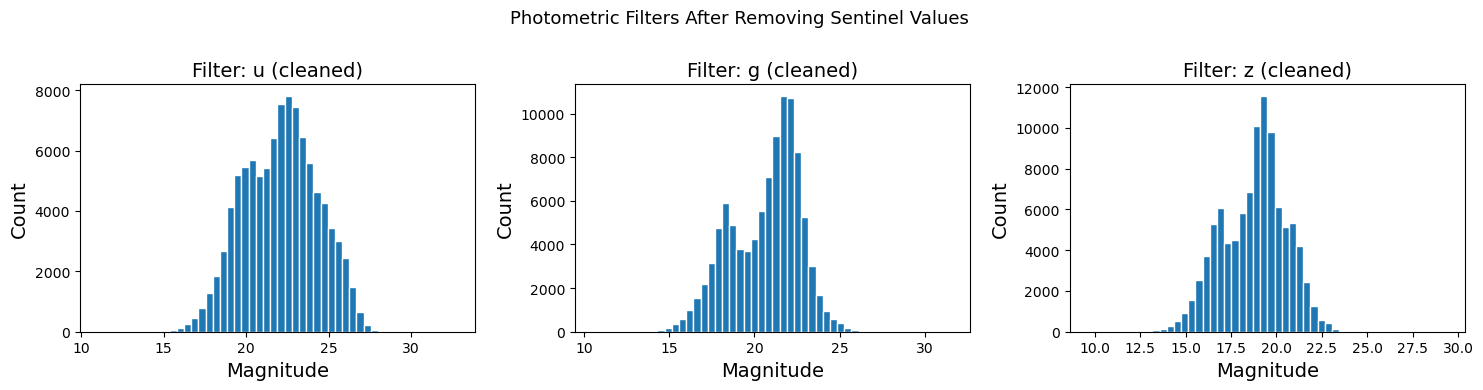

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['u', 'g', 'z']):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='white')
    ax.set_title(f'Filter: {col} (cleaned)')
    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Count')

plt.suptitle('Photometric Filters After Removing Sentinel Values', fontsize=13)
save_fig('ugz_cleaned_distributions')
plt.show()

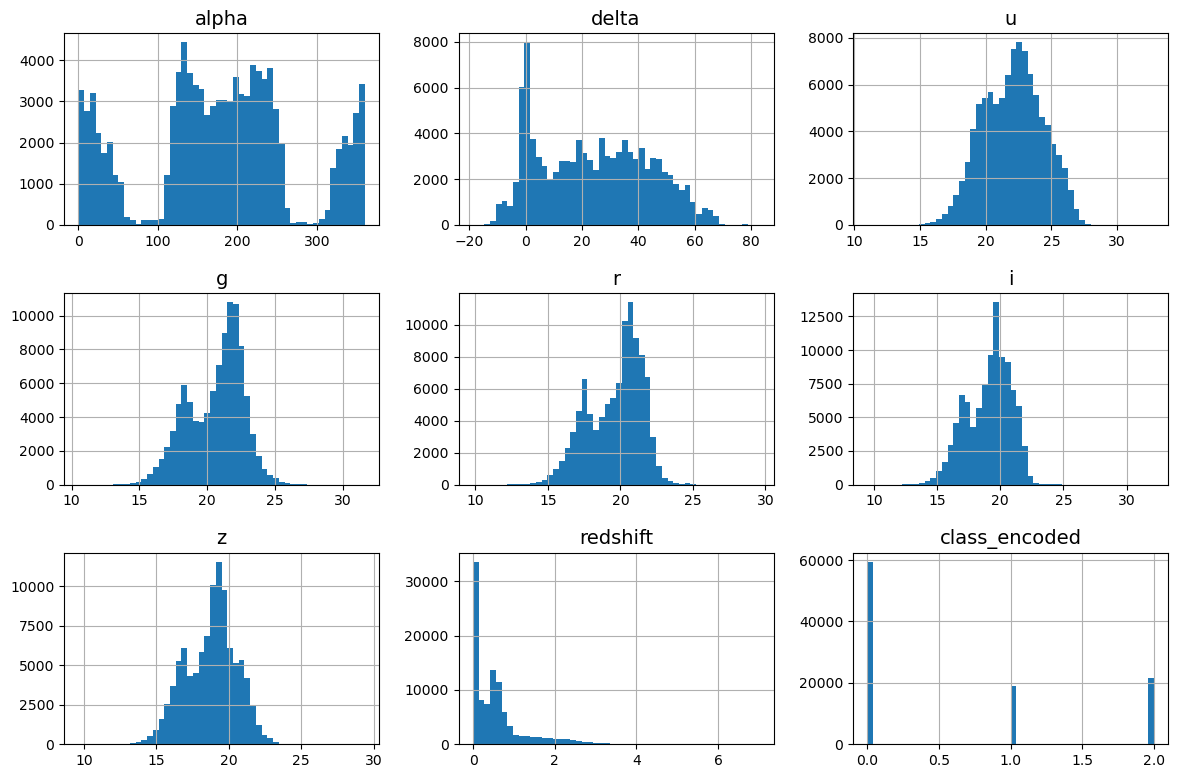

In [22]:
df.hist(bins=50, figsize=(12, 8))
save_fig("corrected_attribute_histogram_plots")
plt.show()

After removing the sentinel values, all three filters now show clean, bell-shaped 
distributions centered in the expected magnitude range of 15–25, consistent with 
real astronomical observations.

**u** peaks around magnitude 22–23, **g** around 21–22, and **z** around 19–20. 
The slight shift toward lower magnitudes from u to z is physically meaningful, 
it reflects the fact that most objects in the survey are relatively brighter in 
the infrared (z) than in the ultraviolet (u), which is typical for galaxies and stars.

The small secondary bump visible in **g** and **z** around magnitude 15–17 likely 
corresponds to the star population, which tends to be brighter than galaxies on average.

### 5.2 Class Distribution

Checking how many objects of each type are in the dataset. An imbalanced distribution (e.g. many more galaxies than quasars) can affect model training and evaluation.

class
GALAXY    59445
STAR      21593
QSO       18961
Name: count, dtype: int64


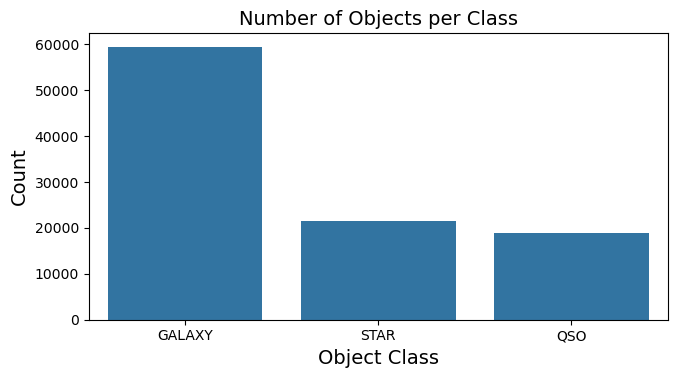

In [23]:
class_counts = df['class'].value_counts()
print(class_counts)

plt.figure(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Number of Objects per Class')
plt.xlabel('Object Class')
plt.ylabel('Count')
save_fig('class_distribution')
plt.show()

From this we can see that there are almost 3 times more galaxies than stars or quasars. It can affect the testing and training and we will consider this distribution of the data when splitting our data. 

### 5.3 Photometric Filter Distributions

Plotting the distribution of each light filter (u, g, r, i, z) split by class. If the distributions differ between classes, the filters will be useful predictors.

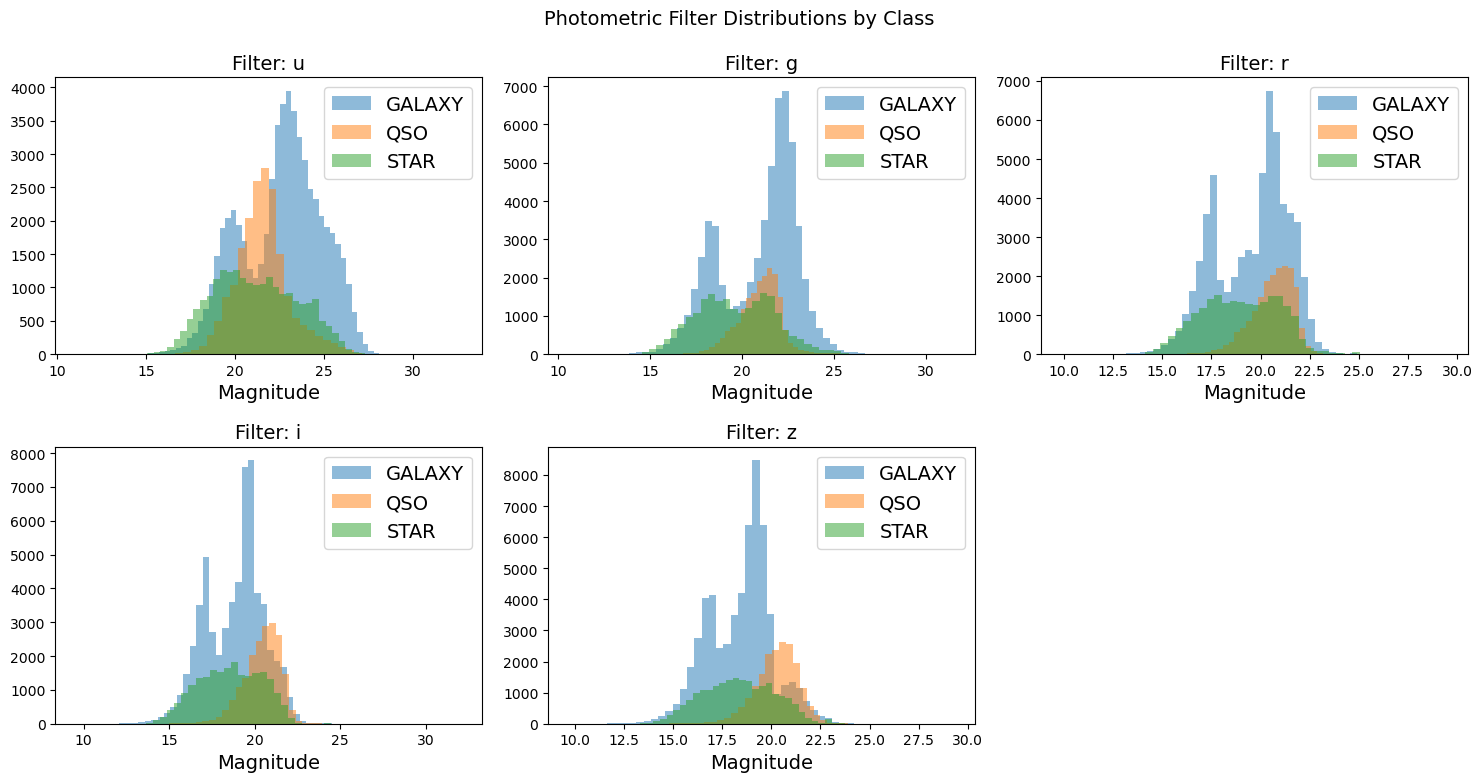

In [24]:
filters = ['u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, f in enumerate(filters):
    for cls in df['class'].unique():
        axes[idx].hist(df[df['class'] == cls][f], bins=50, alpha=0.5, label=cls)
    axes[idx].set_title(f'Filter: {f}')
    axes[idx].set_xlabel('Magnitude')
    axes[idx].legend()

axes[-1].set_visible(False)
plt.suptitle('Photometric Filter Distributions by Class', fontsize=14)
save_fig('filter_distributions')
plt.show()

Across all five filters, galaxies (blue) dominate the dataset numerically and are consistently spread across a wide magnitude range, peaking around 21–23. This is expected given that galaxies make up the majority of the dataset.

Stars (green) stand out clearly in the r, i, and z filters, they form a sharp, narrow peak at lower magnitudes (around 17–18), meaning they tend to be brighter than galaxies in the redder part of the spectrum. This distinct separation suggests that the r, i, and z filters will be useful for identifying stars.

Quasars (orange) largely overlap with galaxies across all filters, which means the photometric filters alone will likely struggle to distinguish between these two classes. This is not surprising as quasars are extremely distant and can appear similar to faint galaxies in terms of raw brightness. This overlap hints that redshift will need to play a key role in separating quasars from galaxies in the model.

Overall, the filters provide some useful signal for classification, particularly for isolating stars, but the galaxy-quasar separation problem will likely require the model to lean heavily on redshift.

### 5.4 Redshift Distribution by Class

Redshift measures how much the light from an object has been stretched as the universe expands and higher redshift means the object is further away. Stars, galaxies, and quasars occupy very different redshift ranges, making this potentially the most powerful single feature.

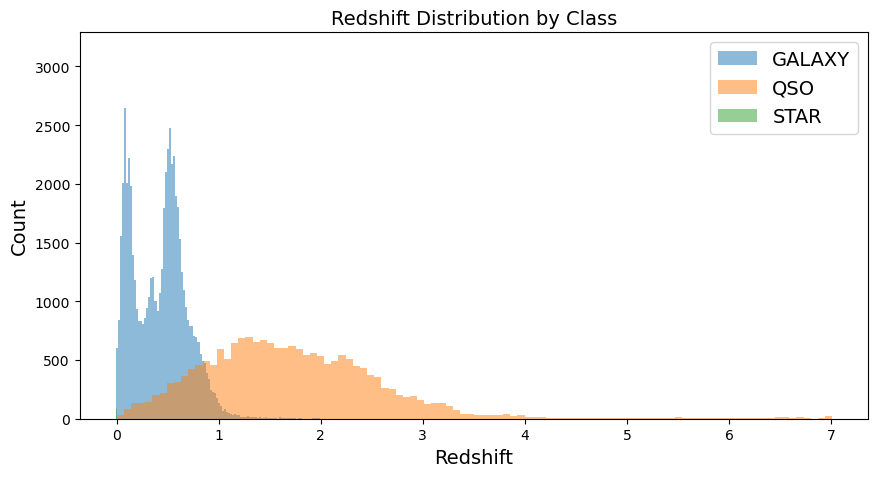

In [25]:
plt.figure(figsize=(9, 5))
for cls in df['class'].unique():
    subset = df[df['class'] == cls]['redshift']
    plt.hist(subset, bins=100, alpha=0.5, label=cls)

plt.title('Redshift Distribution by Class')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.legend()
save_fig('redshift_distribution')
plt.show()

The redshift distribution reveals a very clean separation between the three classes, making it arguably the most powerful feature in the entire dataset.

Stars (green) are essentially invisible on this chart as they sit at a redshift of almost exactly 0 across the board. This makes physical sense, as stars are within our own galaxy and are close enough that their light has not been meaningfully stretched by the expansion of the universe.

Galaxies (blue) cluster tightly between redshifts 0 and 1, with a sharp peak around 0.1–0.6. This reflects the survey's depth, most observed galaxies are relatively nearby on a cosmic scale, though still millions of light years away.

Quasars (orange) tell a completely different story. Their distribution is much broader, spreading from 0.5 all the way out to 7, with a peak around 1.5–2.5. Quasars are among the most distant objects ever observed, and their high redshift values are a direct consequence of the vast distances their light has travelled to reach us.

This plot confirms what was suspected in the filter analysis. Redshift alone can almost perfectly separate stars from the other two classes, and provides strong signal 
for distinguishing galaxies from quasars as well. It will almost certainly emerge as the most important feature in the model.

### 5.6 Pairplot - Filters vs Redshift

A pairplot showing how pairs of features separate the three classes visually. This gives a quick intuition for which feature combinations are most discriminative.

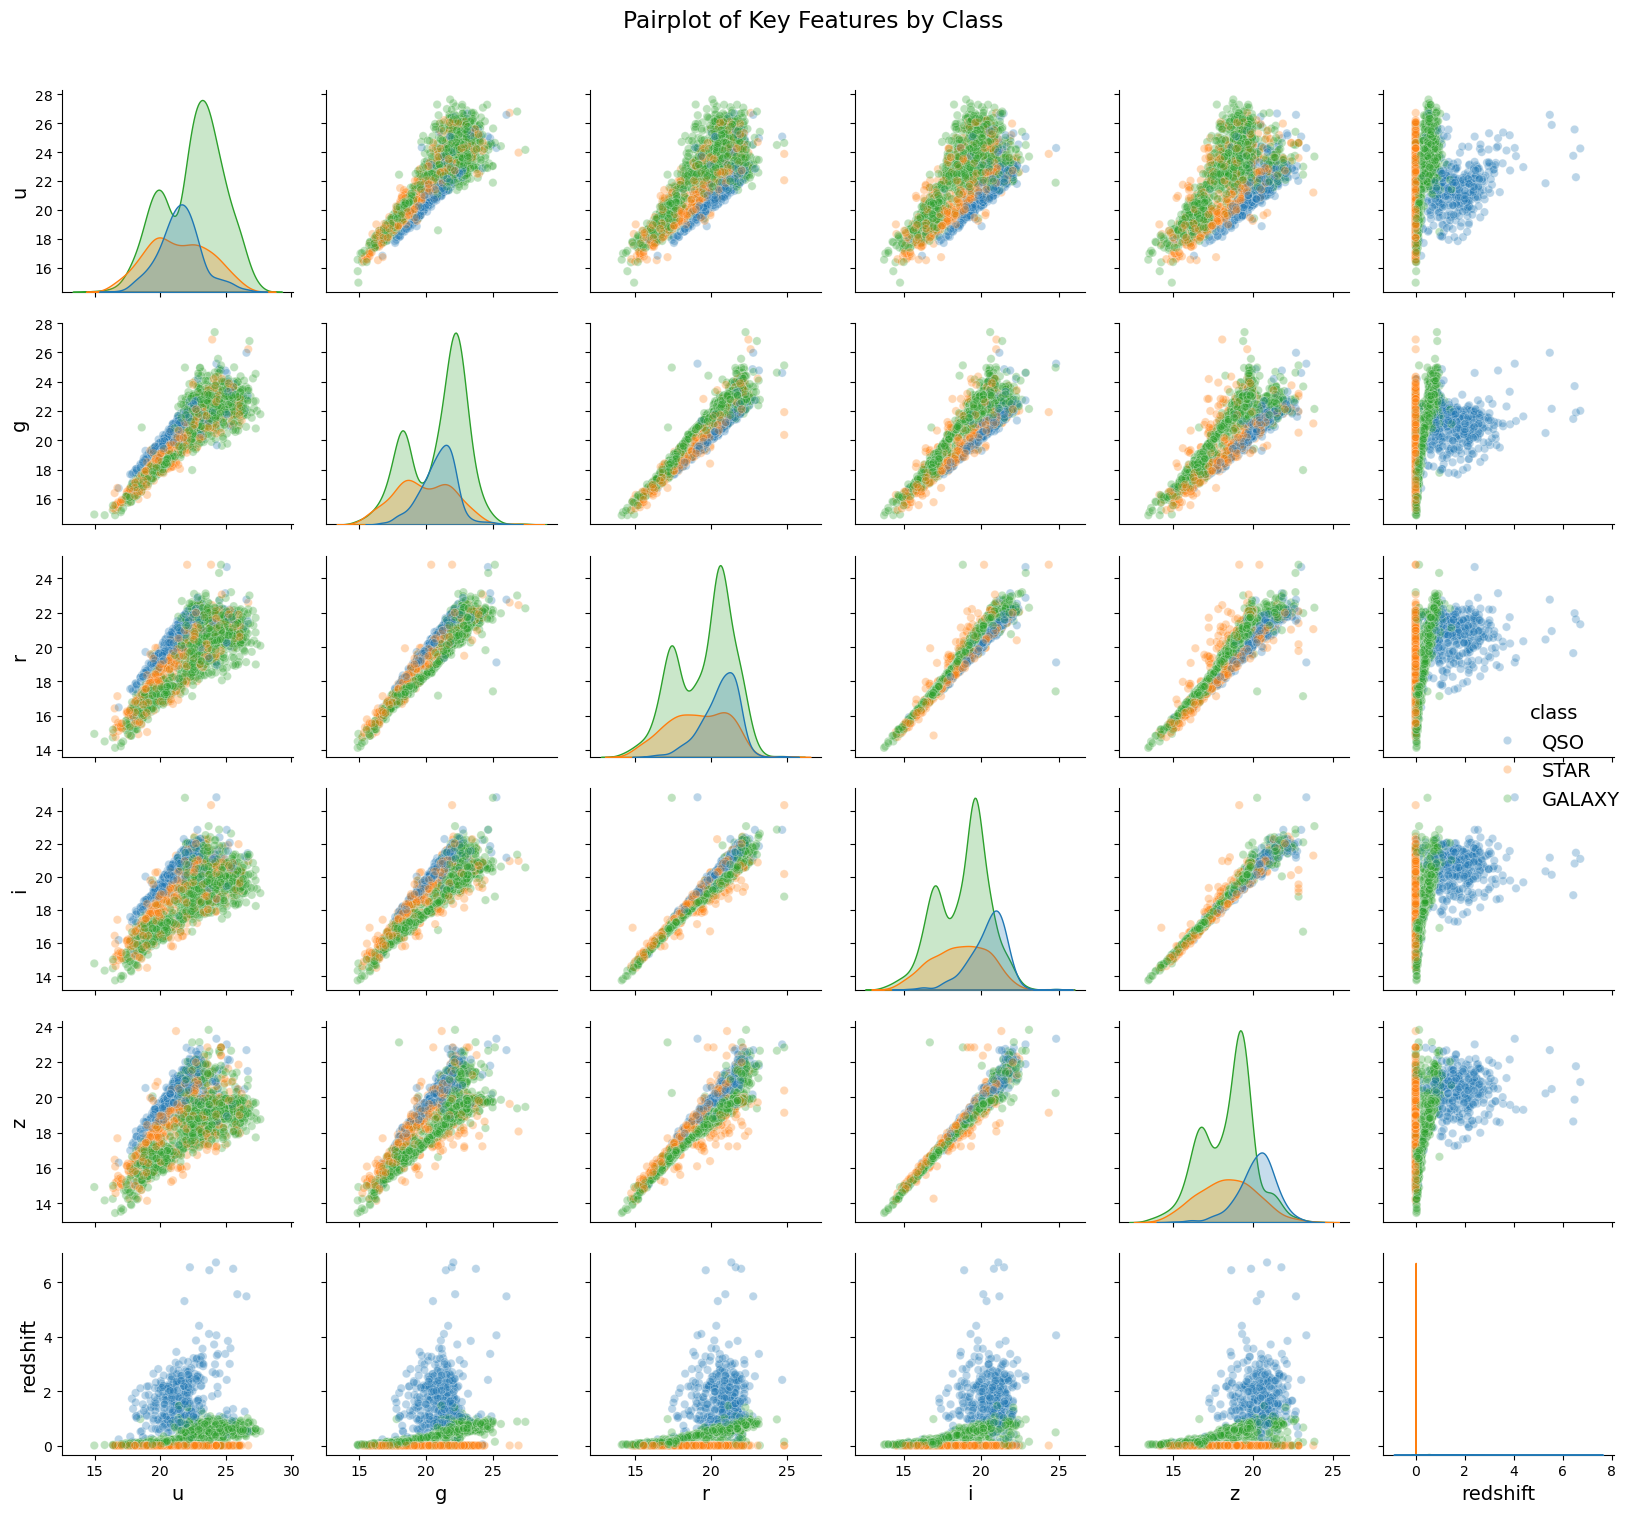

In [26]:
sample = df.sample(2000, random_state=42) 
sns.pairplot(sample[['u', 'g', 'r', 'i', 'z', 'redshift', 'class']], hue='class', plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot of Key Features by Class', y=1.01)
save_fig('pairplot')
plt.show()

The pairplot gives a comprehensive view of how features relate to each other and how well they separate the three classes when combined in pairs.

The **filter vs filter scatter plots** (the upper-left block of the grid) all show a tight diagonal band where all three classes overlap heavily. This confirms what the correlation matrix already suggested. The filters move together and are not particularly useful for separating classes on their own. Galaxies (green) and quasars (orange) are almost completely mixed, while stars (blue in this plot) blend in as well.

The **diagonal plots** (the distributions along the diagonal) are interesting, the r, i, and z filters each show a double-peaked distribution for stars, which hints at two distinct stellar populations in the survey with different brightness profiles.

The most revealing column is the **redshift column** (bottom row and rightmost column). When any filter is plotted against redshift, the three classes immediately pull apart: stars collapse into a flat line at redshift around 0, galaxies spread along the lower redshift range, and quasars scatter upward to much higher redshift values. This pattern is consistent across every filter, reinforcing that redshift is by far the strongest separating feature in the dataset regardless of which filter it is paired with.

Overall, the pairplot confirms that no single pair of photometric filters can cleanly separate the three classes, but any combination involving redshift produces strong and immediate separation, particularly between stars and everything else.

### 5.7 Boxplots - Key feature distributions

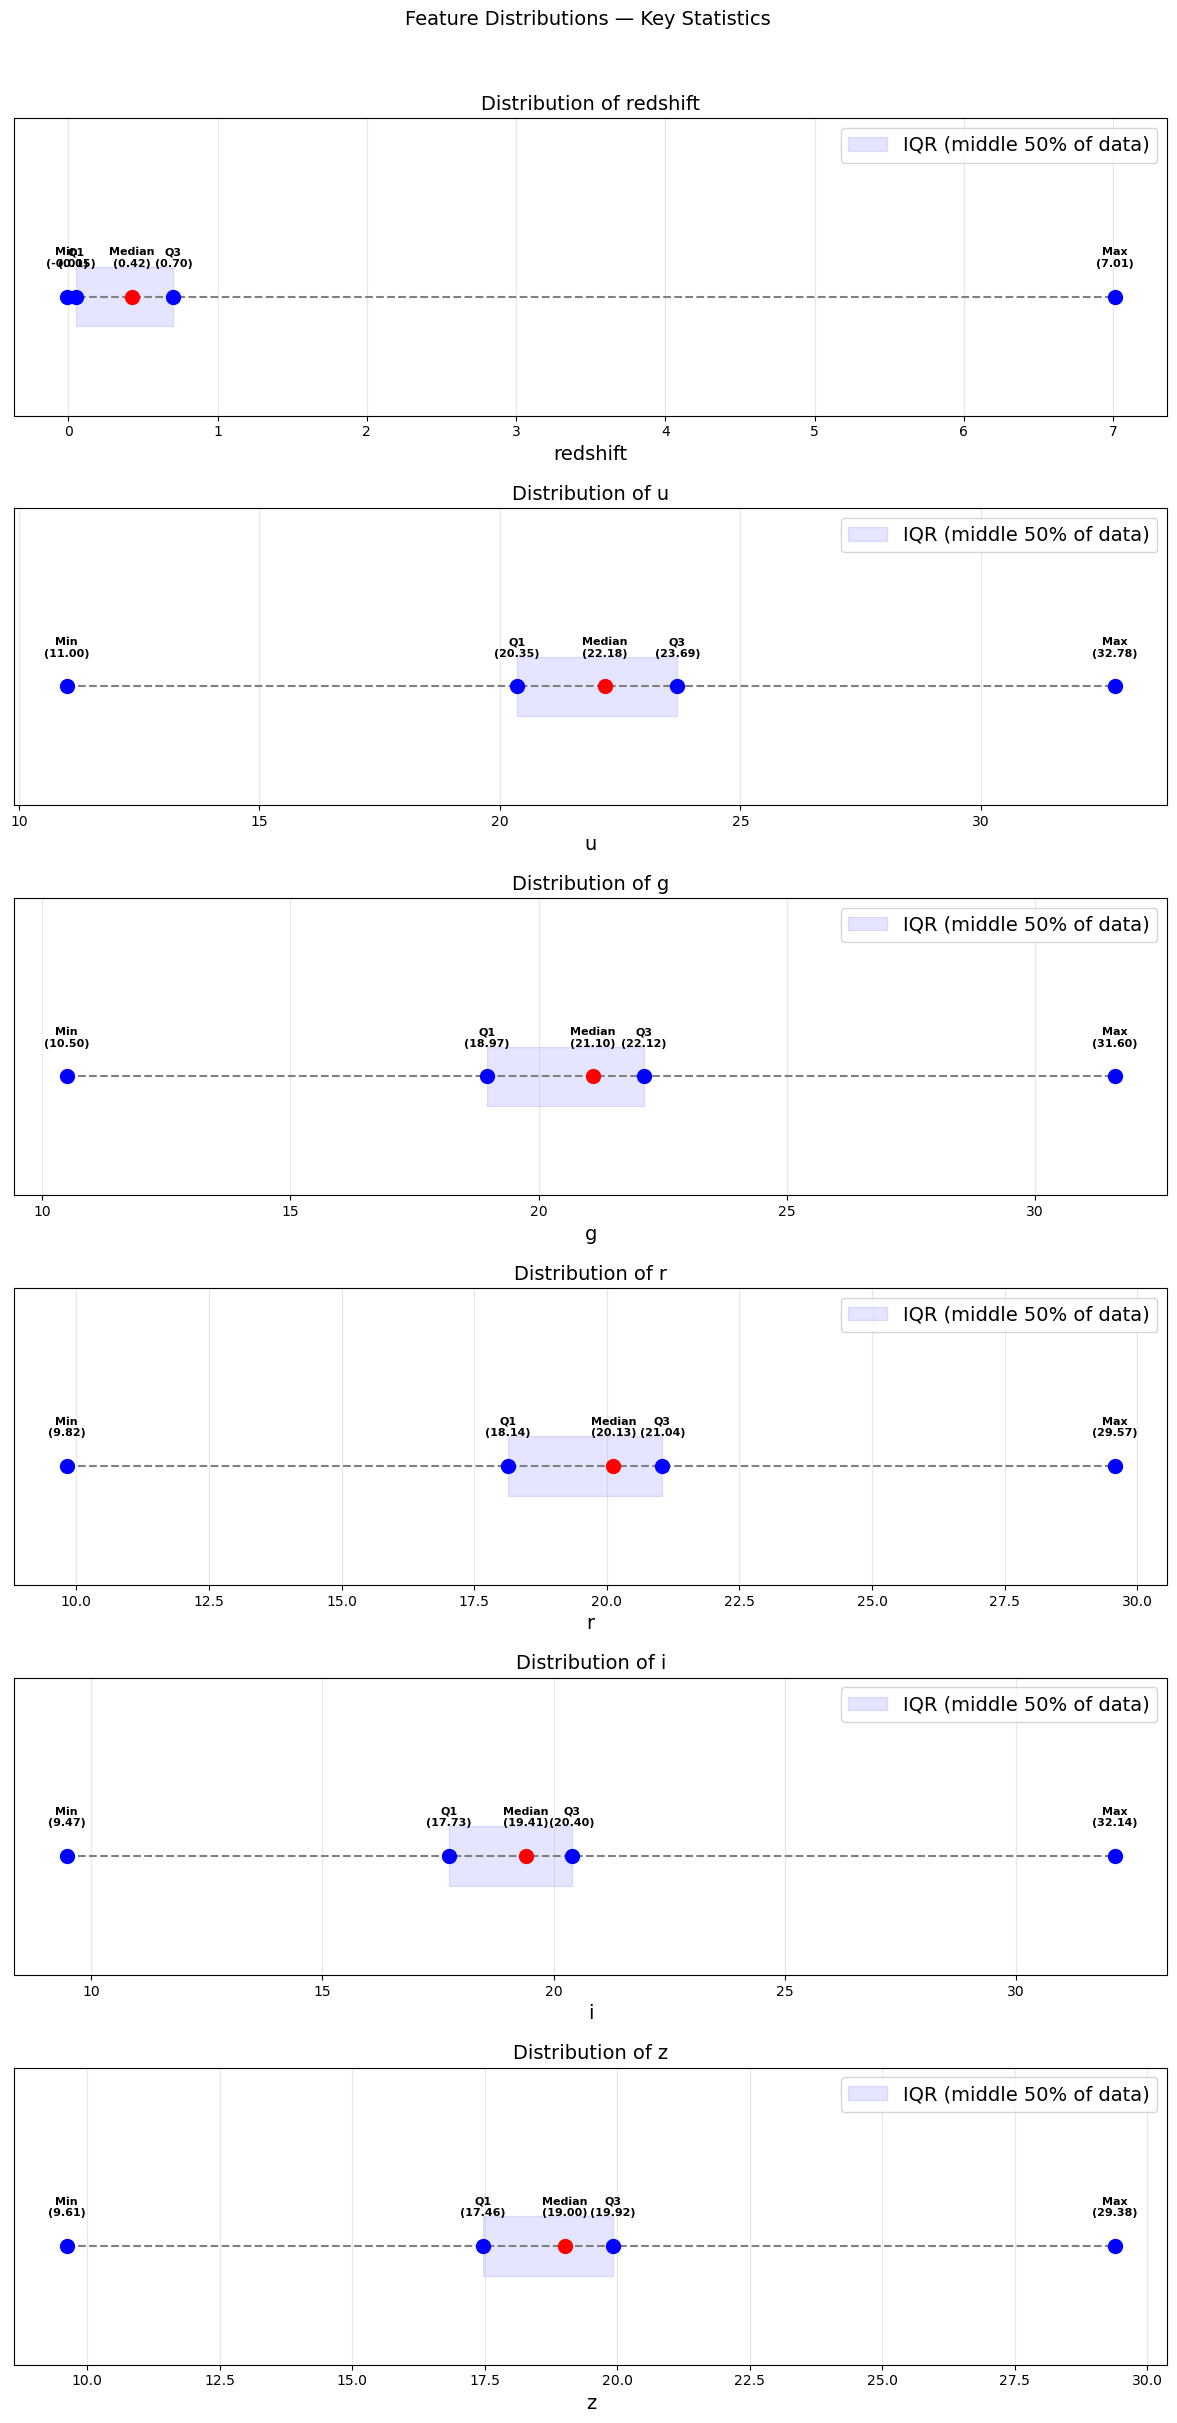

In [27]:
features = ['redshift', 'u', 'g', 'r', 'i', 'z']

fig, axes = plt.subplots(len(features), 1, figsize=(12, 4 * len(features)))

for ax, feature in zip(axes, features):
    stats = df[feature].describe()

    ax.hlines(1, stats['min'], stats['max'], colors='gray', linestyles='--')

    points = {
        'Min':    stats['min'],
        'Q1':     stats['25%'],
        'Median': stats['50%'],
        'Q3':     stats['75%'],
        'Max':    stats['max']
    }

    for label, val in points.items():
        color = 'red' if label == 'Median' else 'blue'
        ax.plot(val, 1, 'o', markersize=10, color=color)
        ax.text(val, 1.05, f"{label}\n({val:.2f})", ha='center', fontweight='bold', fontsize=8)

    ax.fill_between(
        [stats['25%'], stats['75%']], 0.95, 1.05,
        color='blue', alpha=0.1, label='IQR (middle 50% of data)'
    )

    ax.set_ylim(0.8, 1.3)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_yticks([])
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Distributions — Key Statistics', fontsize=14, y=1.01)
save_fig('feature_distribution_boxplots')
plt.show()

These distribution plots show the spread of redshift and all five raw photometric filters after cleaning, and paint a consistent picture across the dataset.

**Redshift** remains the most skewed feature, the IQR is extremely narrow (0.05 to 0.70) with a median of just 0.42, yet the maximum reaches 7.01. The vast 
majority of objects sit very close to zero, with only a small fraction of distant quasars pulling the tail far to the right.

**The photometric filters (u, g, r, i, z)** all show a much more balanced and well-behaved distribution compared to redshift. Their key statistics are:

- **u**: IQR from 20.35 to 23.69, median 22.18
- **g**: IQR from 18.97 to 22.12, median 21.10
- **r**: IQR from 18.14 to 21.04, median 20.13
- **i**: IQR from 17.73 to 20.40, median 19.41
- **z**: IQR from 17.46 to 19.92, median 19.00

A clear and physically meaningful pattern emerges, moving from u to z, both the median and the IQR shift progressively toward lower magnitude values. Since lower magnitude means brighter, this tells us that the objects in this survey are consistently brighter in the infrared (z) end of the spectrum than in the ultraviolet (u) end, which is typical for galaxies and stars.

All five filters have similar IQR widths of roughly 3 magnitude units, suggesting comparable spread across the spectrum. The minimum values around 10–11 and maximum values around 29–33 indicate some outliers at both ends, though these are far less extreme than what was seen in the color indices, confirming that the raw filters are generally cleaner and more normally distributed features.

---
## 6. Feature Engineering

Creating new features from the existing ones that may help the model better distinguish between object classes.

In the previous section we saw that no photometric filter alone is able to tell us much about the data as they overlap in most parts. To try to provide better information we will add 4 new columns, each a difference of 2 filters. In this section we will analyze again the dataset but with focus on how these new columns affect the classification.

### 6.1 Color Indices

In astronomy, the difference in brightness between two filters is called a **color index**. It is a standard way to characterize objects and is often more informative than raw filter magnitudes alone.

In [28]:
df['u_g'] = df['u'] - df['g']  # Ultraviolet minus green
df['g_r'] = df['g'] - df['r']  # Green minus red
df['r_i'] = df['r'] - df['i']  # Red minus near-infrared
df['i_z'] = df['i'] - df['z']  # Near-infrared minus infrared

print('Color index columns added.')
df[['u_g', 'g_r', 'r_i', 'i_z']].describe()

Color index columns added.


,u_g,g_r,r_i,i_z
count,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.449096,0.985806,0.560912,0.315877
std,1.179332,0.734675,0.501518,0.420396
min,-12.748140,-12.318610,-14.649070,-13.162490
25%,0.631245,0.379810,0.216320,0.134500
50%,1.321710,0.931460,0.479800,0.338030
75%,2.044565,1.577985,0.892205,0.474080
max,18.624950,14.315170,12.205800,13.427100


### 6.2 Color Index Distributions by Class

Verifying that the new color index features actually separate the three classes better than the raw filter values did.

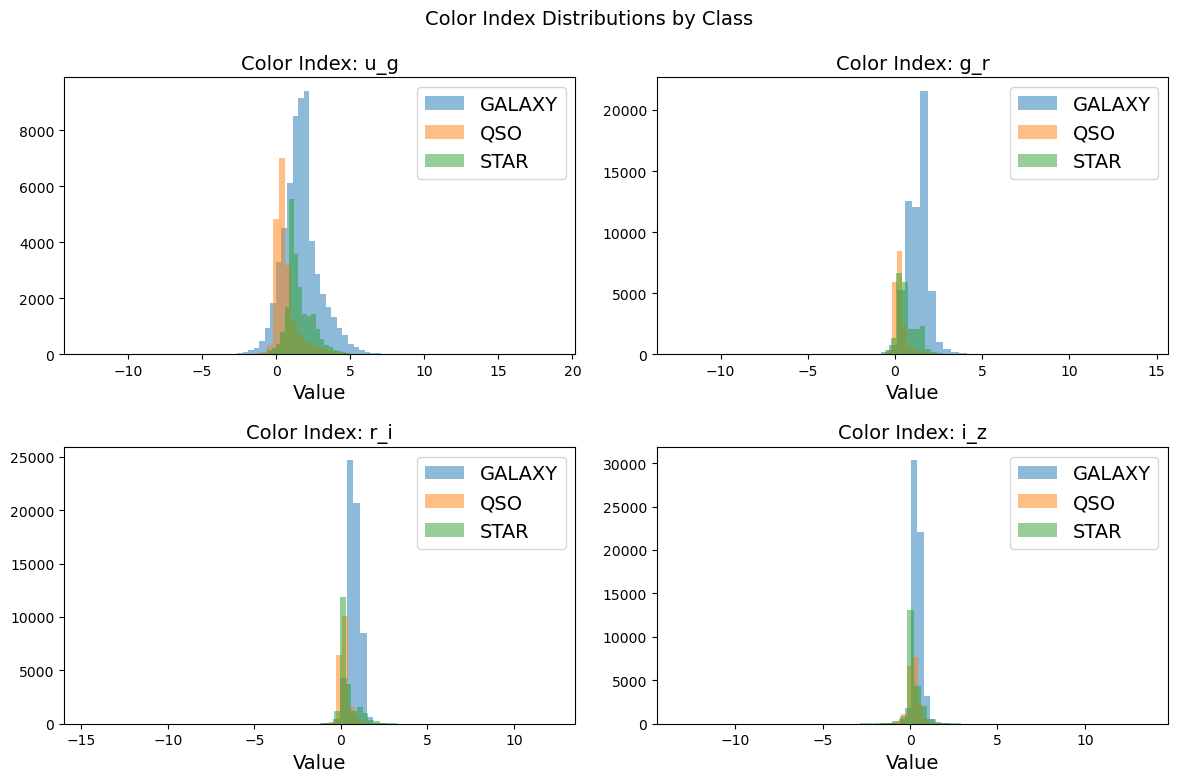

In [29]:
color_indices = ['u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, ci in enumerate(color_indices):
    for cls in df['class'].unique():
        axes[idx].hist(df[df['class'] == cls][ci], bins=60, alpha=0.5, label=cls)
    axes[idx].set_title(f'Color Index: {ci}')
    axes[idx].set_xlabel('Value')
    axes[idx].legend()

plt.suptitle('Color Index Distributions by Class', fontsize=14)
save_fig('color_index_distributions')
plt.show()

The color index distributions reveal some useful class separation, though with varying degrees of effectiveness across the four indices.

For **u-g** (ultraviolet minus green), the three classes overlap heavily around 1–4, but quasars (orange) show a noticeably wider and flatter spread, with a longer left tail extending toward negative values. This makes sense physically, quasars have unusual ultraviolet emission properties compared to normal galaxies and stars.

**g-r** (green minus red) shows a similar pattern, with galaxies and stars tightly clustered around 0–2, while quasars again spread more broadly. Stars appear slightly shifted toward lower g-r values compared to galaxies, suggesting they are relatively brighter in the green band.

**r-i** and **i-z** both show very tight distributions centered near 0 for all three classes, with almost complete overlap. These two indices appear to carry the least discriminative power of the four, as adjacent infrared filters capture very similar brightness information regardless of object type.

Overall, the color indices are most useful for identifying quasars due to their broader, more irregular spread (particularly in u-g and g-r). However, the heavy overlap between classes across all four indices confirms that color indices alone are not sufficient for reliable classification, and will work best in combination with redshift inside the model.

### 6.3 Correlation Heatmap

A heatmap of correlations between all numeric features. Highly correlated features (close to 1 or -1) carry redundant information, which is useful to know before training.

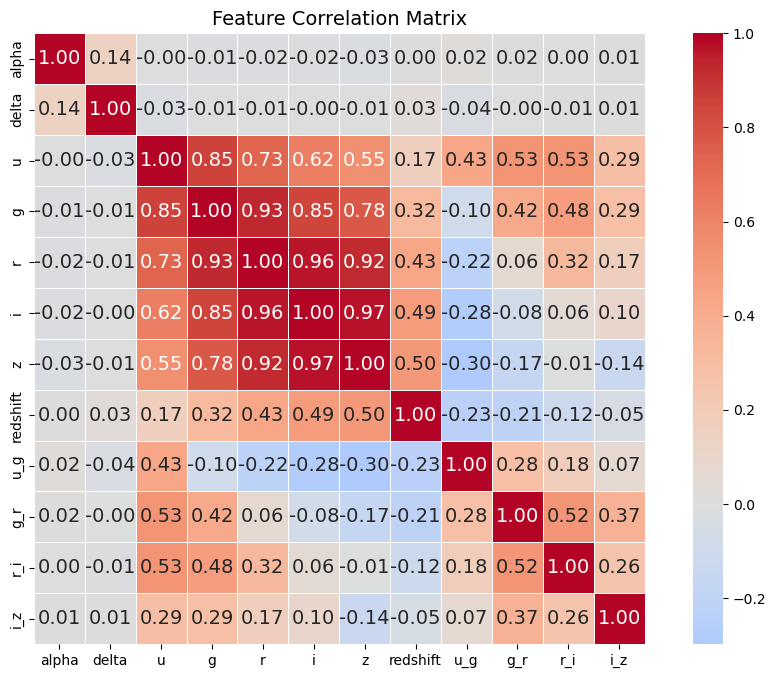

In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns='class_encoded').columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
save_fig('correlation_heatmap')
plt.show()

The correlation matrix reveals two distinct groups of features that behave very differently from each other.

The photometric filters (u, g, r, i, z) are all strongly correlated with each other, with values ranging from 0.55 to 0.97. The adjacent filters in the spectrum, r and i (0.96), i and z (0.97), are almost perfectly correlated, which makes sense since neighboring wavelengths tend to capture similar information about an object's brightness. This high multicollinearity means the filters are somewhat redundant individually, which is exactly why the color index features engineered earlier (differences between filters) are more informative, they capture what makes each filter unique rather than what they all share.

Redshift shows moderate positive correlations with the redder filters (0.43–0.50 for r, i, z) and a weaker one with u (0.17). This is consistent with the physical reality that more distant, high-redshift objects tend to appear fainter and redder.

Alpha and delta, the sky coordinates, show virtually no correlation with any other feature (all values near 0), which confirms that they carry no useful predictive information and should be dropped before training the model.

### 6.4 Pairplot — Color Indices vs Redshift

Let's look again at how pairs of new features separate the three classes visually.

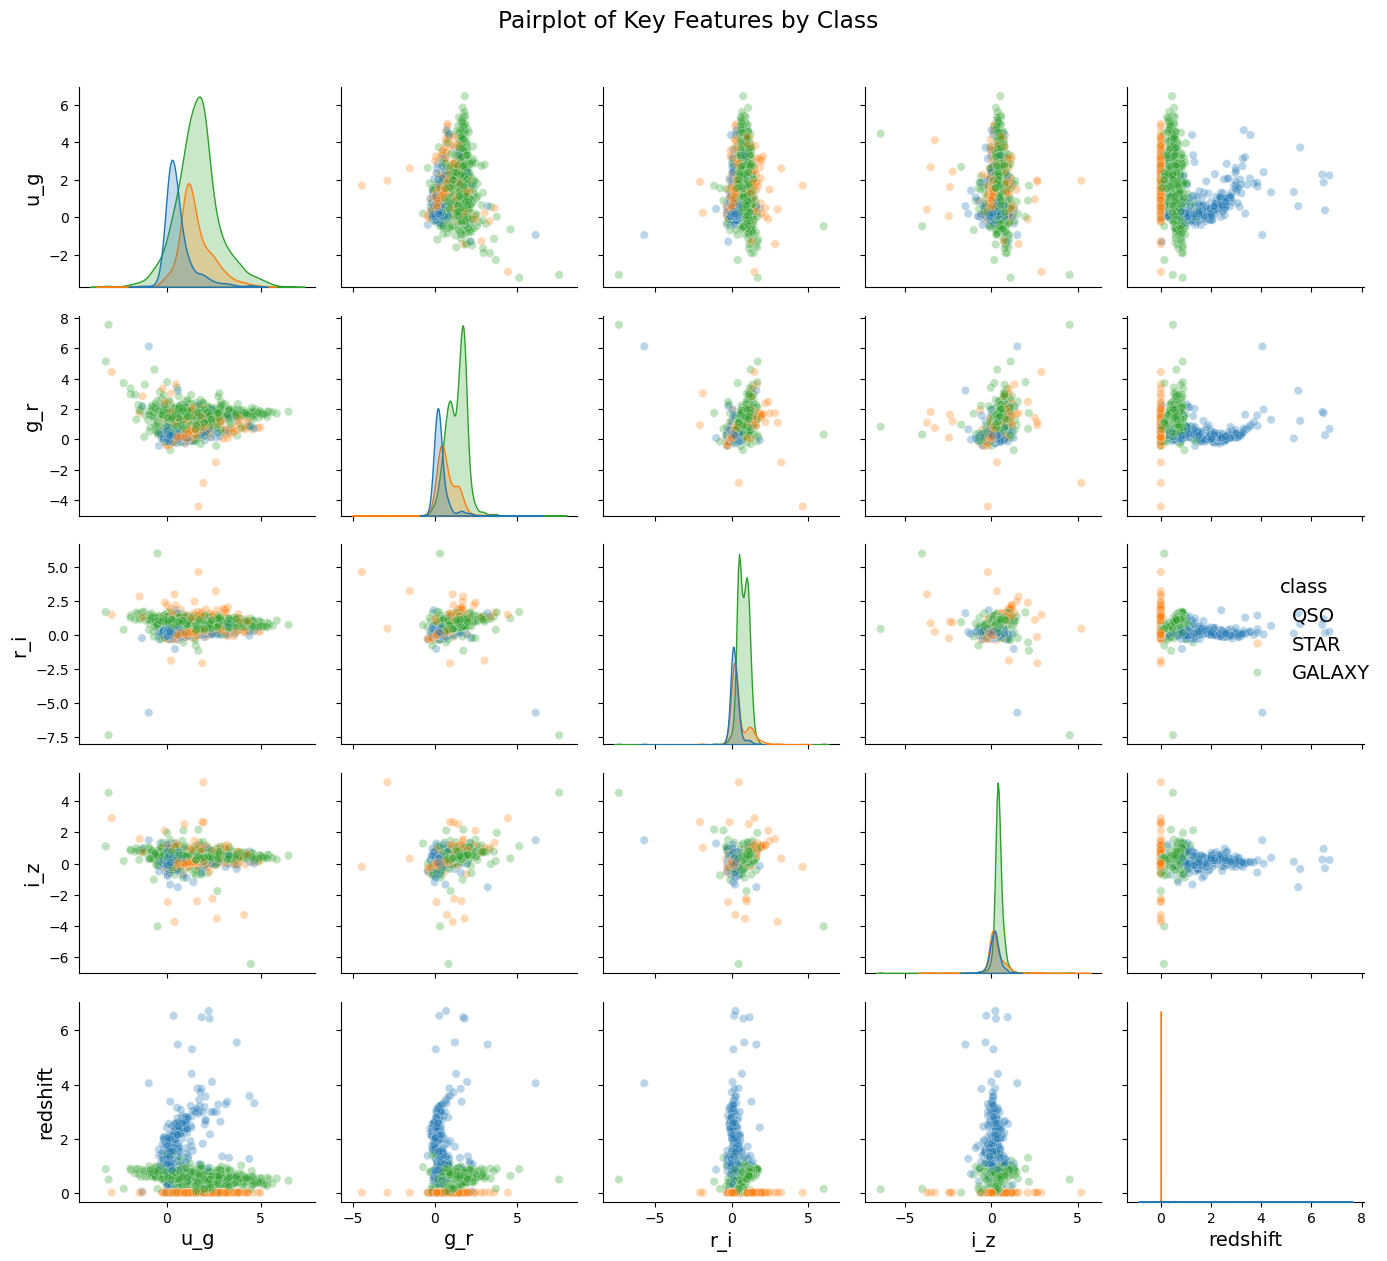

In [31]:
sample = df.sample(2000, random_state=42)
sns.pairplot(sample[['u_g', 'g_r', 'r_i', 'i_z', 'redshift', 'class']], hue='class', plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot of Key Features by Class', y=1.01)
save_fig('pairplot')
plt.show()

This pairplot focuses on the engineered color index features alongside redshift, and tells a more nuanced story than the raw filter pairplot.

The **u-g diagonal** shows the clearest separation among the color indices: galaxies (green) peak around 1–2, stars (grey) sit slightly lower, and quasars (orange) have a flatter, wider distribution centered around 0–1. This spread in u-g is physically meaningful, as quasars emit unusually strong ultraviolet radiation which pulls their u-g values toward lower or even negative numbers.

The **g-r diagonal** shows galaxies with a very sharp, tall peak near 0.5, while quasars and stars are more spread out and overlapping. The tightness of the galaxy distribution here suggests that most galaxies in the survey have a very consistent green-to-red brightness ratio.

The **r-i and i-z diagonals** are extremely narrow and nearly identical across all three classes, confirming again that these two indices carry very little discriminative power between object types.

In the **scatter plots between color indices**, all three classes form a dense central blob with considerable overlap and no clean boundaries, meaning no single pair of color indices can reliably separate the classes on its own.

Once again the **redshift column** stands out dramatically, plotting any color index against redshift immediately pulls quasars upward and away from the other two classes, while stars collapse to a vertical line at zero. Notably, the u-g vs redshift plot shows a slight upward trend for quasars, suggesting that more distant quasars tend to have higher u-g values, which is a known spectral effect caused by redshifting of their ultraviolet emission into the visible range.

### 6.5 Scatter matrix across filters and redshift

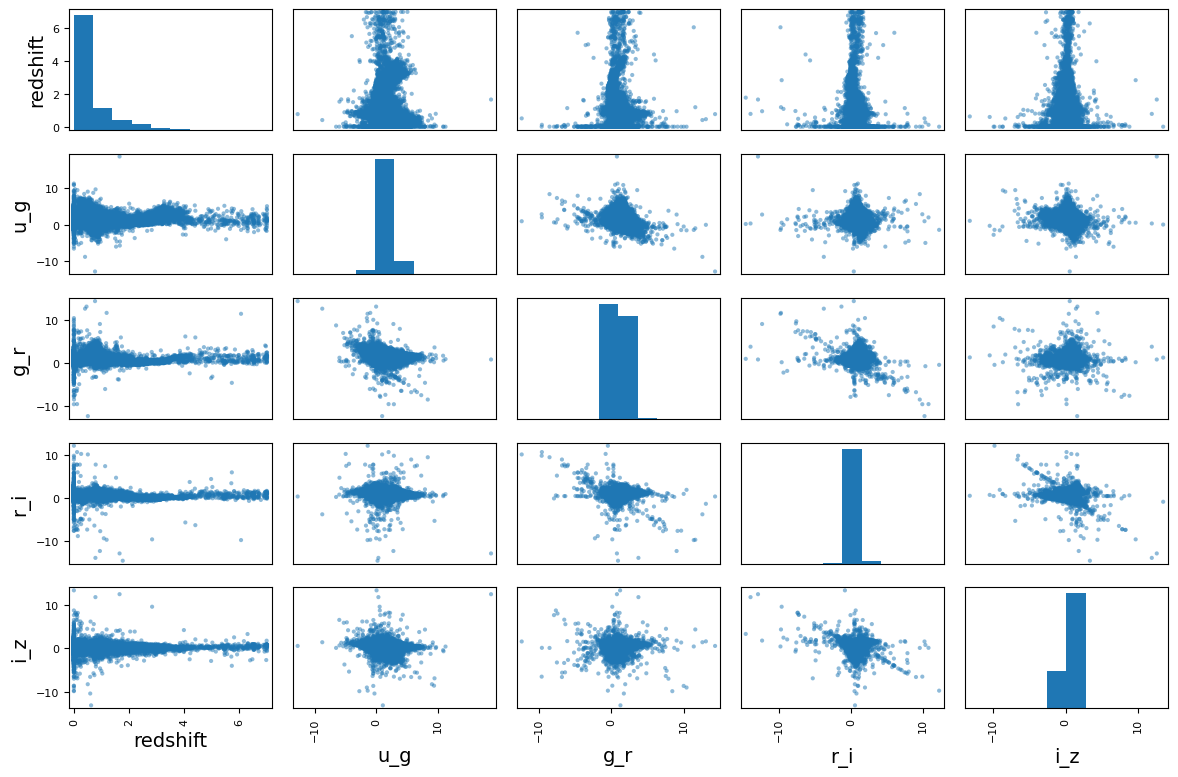

In [32]:
attributes = ["redshift", "u_g", "g_r", "r_i", "i_z"]
scatter_matrix(df[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")
plt.show()

This scatter matrix focuses exclusively on redshift and the four color indices, and provides a cleaner view of how these engineered features relate to each other compared to the earlier pairplot.

The **diagonal histograms** confirm what we already knew. Redshift is heavily right-skewed with most values near zero, while all four color indices are tightly centered around 0 with very long tails in both directions. The two-bar appearance of the color index histograms is a visual artifact of the extreme outliers compressing the central distribution into a single tall bar.

Looking at **redshift vs the color indices** (first column and first row), a subtle fan-shaped pattern is visible at low redshift values the color indices are tightly clustered near zero, but as redshift increases the spread widens significantly, particularly for u_g and g_r. This suggests that higher redshift objects (mostly quasars) show more varied color profiles, which is physically consistent with the diverse spectral properties of quasars at different distances.

Among the **color index pairs** (the inner 4x4 block), all combinations show a similar diamond or cross-shaped scatter pattern, a dense core near (0, 0) with outliers radiating outward in all directions. This indicates that the color indices are largely uncorrelated with each other for the majority of objects, but that extreme values in one index tend to appear alongside extreme values in others, likely driven by the same unusual objects: most probably quasars or rare stellar types.

Overall this scatter matrix reinforces that redshift carries the most structured and useful signal, while the color indices contribute primarily through their outlier behavior rather than their central distributions.

### 6.6 Boxplots - Color Index Distributions

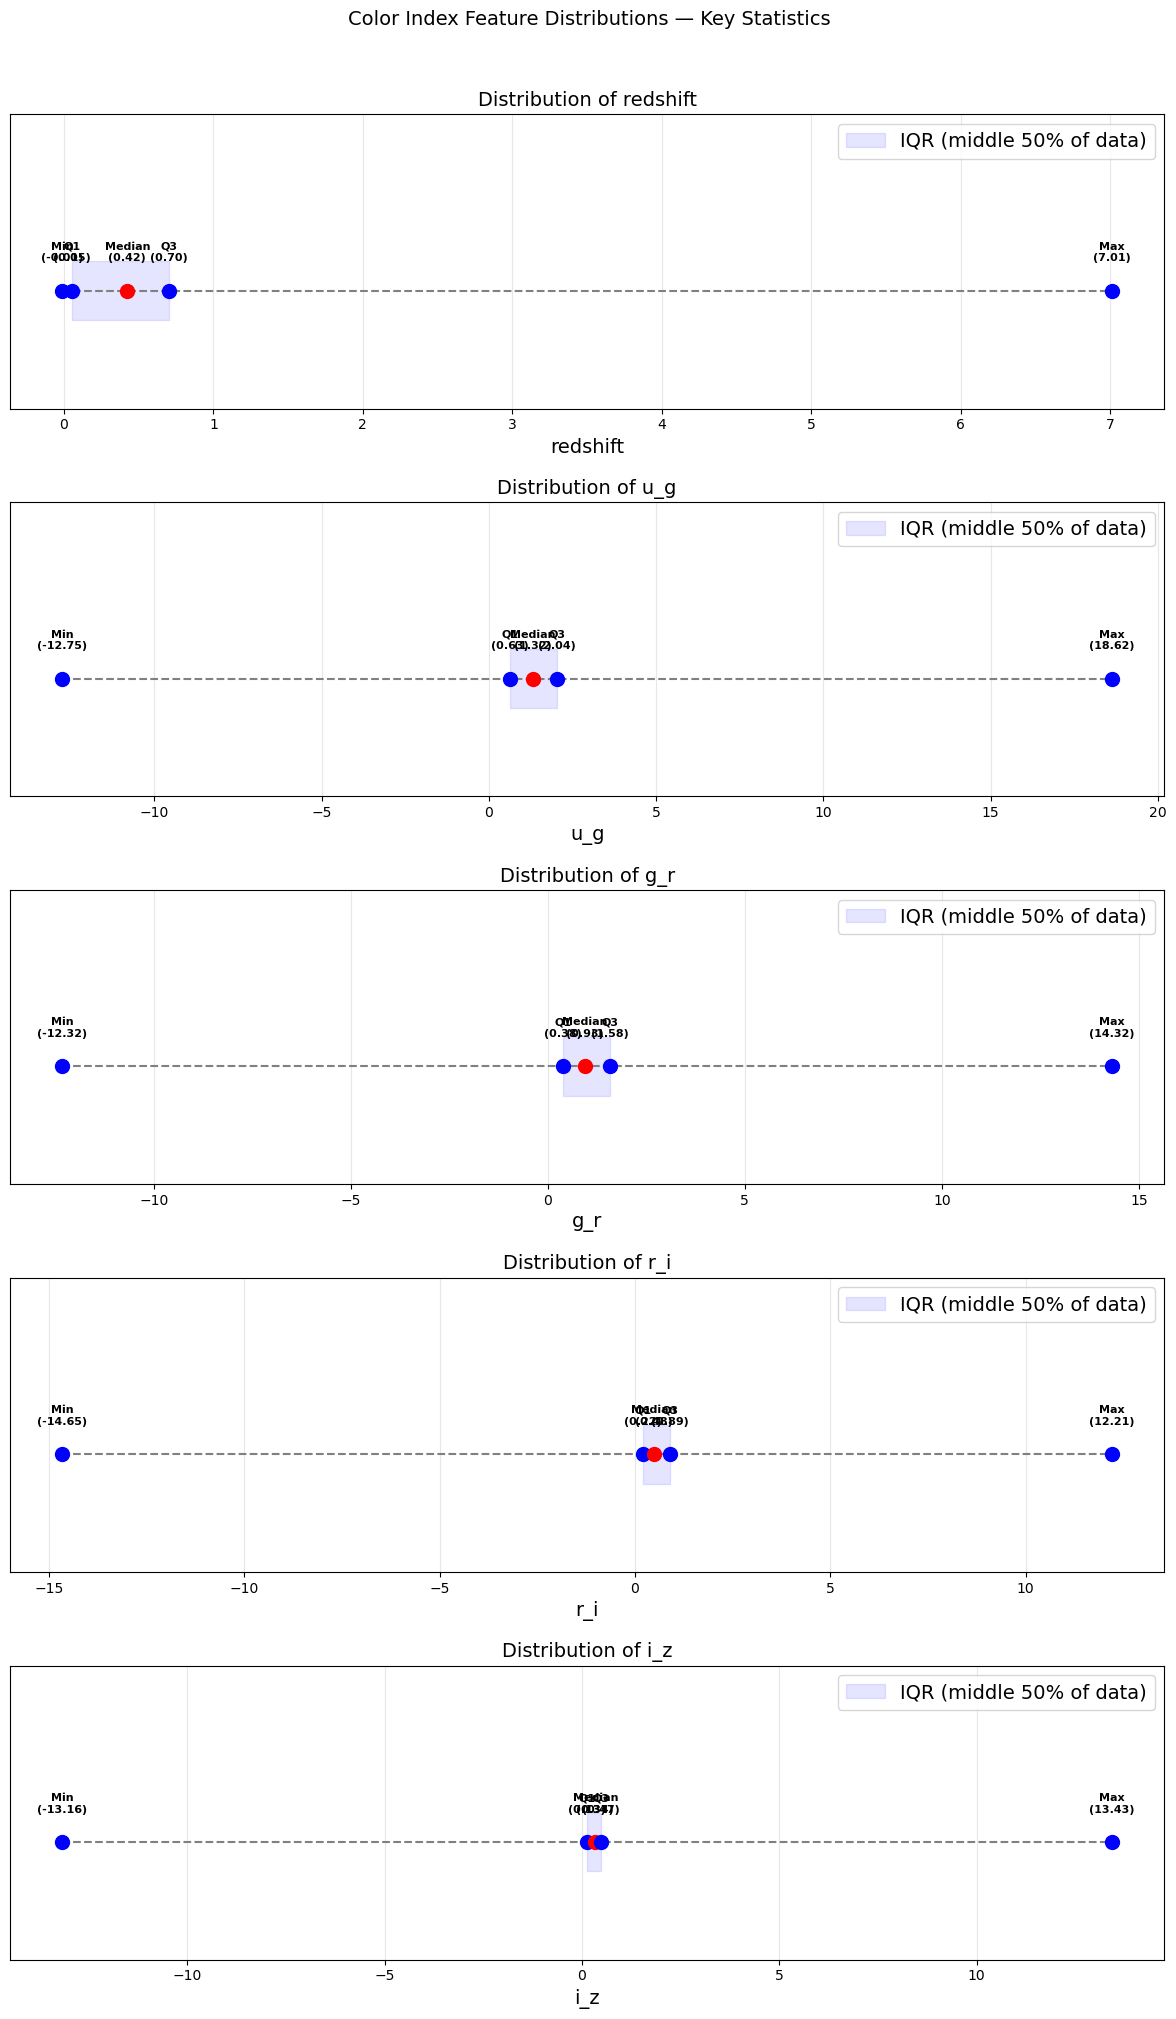

In [33]:
features = ['redshift', 'u_g', 'g_r', 'r_i', 'i_z']

fig, axes = plt.subplots(len(features), 1, figsize=(12, 4 * len(features)))

for ax, feature in zip(axes, features):
    stats = df[feature].describe()

    ax.hlines(1, stats['min'], stats['max'], colors='gray', linestyles='--')

    points = {
        'Min':    stats['min'],
        'Q1':     stats['25%'],
        'Median': stats['50%'],
        'Q3':     stats['75%'],
        'Max':    stats['max']
    }

    for label, val in points.items():
        color = 'red' if label == 'Median' else 'blue'
        ax.plot(val, 1, 'o', markersize=10, color=color)
        ax.text(val, 1.05, f"{label}\n({val:.2f})", ha='center', fontweight='bold', fontsize=8)

    ax.fill_between(
        [stats['25%'], stats['75%']], 0.95, 1.05,
        color='blue', alpha=0.1, label='IQR (middle 50% of data)'
    )

    ax.set_ylim(0.8, 1.3)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_yticks([])
    ax.legend()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Color Index Feature Distributions — Key Statistics', fontsize=14, y=1.01)
save_fig('feature_distribution_boxplots')
plt.show()

These distribution plots reveal important characteristics about each feature's spread and the presence of outliers.

**Redshift** has a median of 0.42 and an IQR between 0.05 and 0.70, meaning the central 50% of objects have relatively low redshift values. However the maximum stretches all the way to 7.01, confirming the long right tail we observed earlier caused by distant quasars. The bulk of the data is heavily concentrated near zero while a small number of extreme values pull the range far to the right.

**u_g** has its central 50% tightly packed between 0.62 and 2.04 with a median of 1.32, but shows extreme outliers in both directions: a minimum of -8.76 and a maximum of 10.92. These outliers likely correspond to quasars with unusual ultraviolet emission profiles, consistent with what we observed in the color index histogram earlier.

**g_r** tells a similar story, the IQR is very narrow (0.30 to 1.58) but the tails extend to -12.32 and 12.57. The extreme negative values are particularly notable and may warrant further investigation as potential measurement anomalies.

**r_i and i_z** both show extremely compressed IQRs centered very close to zero, with their Q1, median and Q3 dots nearly overlapping in the plot. Despite this tight central distribution, both features have substantial outliers reaching beyond ±10. This confirms the earlier finding that these two indices carry very little variation for the majority of objects, making them the least informative features for classification, though the outlier cases may still provide some signal.

Overall, all four color indices share a common pattern: a tight, well-behaved core with long extreme tails driven by unusual objects, most likely quasars.

### 6.7 Outlier Strategy

Examining the distributions revealed the presence of extreme values in several features, particularly in the color indices (u_g, g_r, r_i, i_z) and redshift. However, after careful consideration, no additional rows were removed beyond the sentinel value cleanup performed above.

The key reason is that these outliers are not random measurement errors, they correspond to physically real objects, most likely quasars, which genuinely exhibit unusual spectral profiles compared to stars and galaxies. Removing them would disproportionately reduce the quasar class, which is already the smallest of the three classes in the dataset, and would make the classification problem artificially easier and less representative of real astronomical data.

For these reasons, the outliers are intentionally retained as meaningful signal rather than treated as noise to be discarded.

---
## 7. Data Splitting & Preparation

Splitting the data into training and test sets, and building a preprocessing pipeline to scale features before passing them to the models.

### 7.1 Define Features and Target

Separating the dataset into input features (X) and the target label (y), and removing any columns that should not be used as predictors.

Based on the exploratory data analysis, the decision of which features to keep and which to drop becomes straightforward.

**Alpha and delta** are dropped entirely. These columns represent the sky coordinates of each object, essentially its address in the sky as observed by the SDSS telescope. The correlation matrix confirmed that both have near-zero correlation with every other feature, and conceptually they carry no physical information about what type of object something is. Where an object happens to sit in the sky has nothing to do with whether it is a star, galaxy, or quasar.

**The raw photometric filters (u, g, r, i, z)** are kept alongside the engineered color indices. Even though the filters are correlated with each other, the histogram analysis showed that r, i, and z still provide meaningful separation for the star class in particular. Dropping the raw filters would risk discarding signal that the color indices alone do not fully capture.

**The color indices (u_g, g_r, r_i, i_z)** are kept as additional features on top of the raw filters. By capturing the difference in brightness between adjacent wavelengths rather than absolute brightness, they encode information about an object's spectral shape, which the pairplot analysis showed is particularly useful for identifying quasars due to their unusual ultraviolet emission profile.

**Redshift** is kept as it is by far the most powerful feature in the dataset, providing almost complete separation between stars and the other two classes, and strong signal for distinguishing galaxies from quasars.

In [34]:
drop_cols = ['alpha', 'delta', 'class', 'class_encoded']
X = df.drop(columns=drop_cols)
Y = df['class_encoded']

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Classes  : {label_encoder.classes_}')

Features : 10
Samples  : 99999
Classes  : ['GALAXY' 'QSO' 'STAR']


In [35]:
X.head()

,u,g,r,i,z,redshift,u_g,g_r,r_i,i_z
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,1.60352,1.88029,1.22928,0.37202
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,1.94571,0.24744,1.41632,-0.44615
2,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,2.59918,2.05413,1.26119,0.40030
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,-1.63974,2.16494,1.10708,1.25444
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,1.85690,1.08281,0.52036,0.43250


### 7.2 Train / Validation / Test Split

The data is split into three separate sets, each serving a distinct purpose in the machine learning pipeline.

The **training set (60%)** is what the model actually learns from. All model fitting and parameter estimation happens exclusively on this data.

The **validation set (20%)** is used during model comparison to evaluate how well each candidate model generalizes to data it has not been trained on. By comparing models on the validation set, we can select the best one without touching the test set. This prevents us from unconsciously tuning our choices toward the test data.

The **test set (20%)** is kept completely untouched until the very end of the project. It serves as the final, unbiased estimate of how the chosen model would perform on genuinely new, unseen data, simulating real-world deployment. Using it only once at the end ensures that the reported performance is honest and not inflated by repeated evaluation cycles.

This three-way split is preferable to a simple train/test split precisely because we are comparing multiple models, without a dedicated validation set, every time we checked performance on the test set to compare models we would be leaking information about it into our decision making process.

We should use a stratified splitting to ensure the class proportions are preserved in the split. In this project, we will stratify based on the class column since we have an imbalanced datase (many more galaxies than quasars and stars).

In [36]:
# first checking class proportions before splitting
print("Class proportions in full dataset:")
print((df['class'].value_counts() / len(df) * 100).round(2))

# then doing stratified train/test split on class
train_set, test_set = train_test_split(
    df, test_size=0.2, stratify=df['class'], random_state=42
)

# then doing stratified train/validation split on class
train_set, val_set = train_test_split(
    train_set, test_size=0.25, stratify=train_set['class'], random_state=42
)

# lastly, verify proportions are preserved across all three sets
compare_props = pd.DataFrame({
    'Overall %':    df['class'].value_counts() / len(df),
    'Train %':      train_set['class'].value_counts() / len(train_set),
    'Validation %': val_set['class'].value_counts() / len(val_set),
    'Test %':       test_set['class'].value_counts() / len(test_set),
}).round(4) * 100

print(compare_props)

print(f'\nTrain size      : {len(train_set)} rows ({len(train_set)/len(df)*100:.0f}%)')
print(f'Validation size : {len(val_set)} rows ({len(val_set)/len(df)*100:.0f}%)')
print(f'Test size       : {len(test_set)} rows ({len(test_set)/len(df)*100:.0f}%)')

Class proportions in full dataset:
class
GALAXY    59.45
STAR      21.59
QSO       18.96
Name: count, dtype: float64
        Overall %  Train %  Validation %  Test %
class                                           
GALAXY      59.45    59.45         59.44   59.44
STAR        21.59    21.59         21.60   21.60
QSO         18.96    18.96         18.96   18.96

Train size      : 59999 rows (60%)
Validation size : 20000 rows (20%)
Test size       : 20000 rows (20%)


In [37]:
# Separate features and target for each split
X_train = train_set.drop(columns=['alpha', 'delta', 'class', 'class_encoded'])
y_train = train_set['class_encoded'].copy()

X_val = val_set.drop(columns=['alpha', 'delta', 'class', 'class_encoded'])
y_val = val_set['class_encoded'].copy()

X_test = test_set.drop(columns=['alpha', 'delta', 'class', 'class_encoded'])
y_test = test_set['class_encoded'].copy()

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape  : {X_val.shape}')
print(f'X_test shape : {X_test.shape}')

X_train shape: (59999, 10)
X_val shape  : (20000, 10)
X_test shape : (20000, 10)


Check again for any remaining missing values.

In [38]:
X_train.isnull().sum()

u           0
g           0
r           0
i           0
z           0
redshift    0
u_g         0
g_r         0
r_i         0
i_z         0
dtype: int64

This confirms two things: we have no missing data and also that all the attributes are numbers. 

### 7.3 Preprocessing Pipeline

Scaling all numeric features to the same range using StandardScaler. This is important for distance-based models like KNN and logistic regression, which are sensitive to feature magnitudes.

Rather than applying imputation and scaling as separate manual steps, we combine them into a single sklearn Pipeline. This has two important advantages.

First, it prevents **data leakage**, by wrapping both steps together, we ensure that the imputer and scaler are always fitted on training data only and then applied to validation and test data, never the other way around. If we fitted the scaler on the full dataset before splitting, information from the test set would leak into the training process, giving us an overly optimistic estimate of performance.

Second, it makes the code **cleaner and less error-prone**, instead of manually calling fit and transform separately for each split, the pipeline handles the correct sequence automatically. When we call fit_transform on the training set and transform on the validation and test sets, the pipeline guarantees that exactly the same transformations learned from the training data are applied consistently everywhere.

Note that our dataset has no missing values after the sentinel value cleanup, so the imputer will not actually change any values here. It is included as a safeguard, a good practice in case the pipeline is ever applied to new data that may have gaps.

In [39]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Apply the preprocessor to our data.

In [40]:
X_train_prepared = preprocessor.fit_transform(X_train)
X_val_prepared   = preprocessor.transform(X_val)
X_test_prepared  = preprocessor.transform(X_test)

print(f'X_train_prepared shape: {X_train_prepared.shape}')
print(f'X_val_prepared shape  : {X_val_prepared.shape}')
print(f'X_test_prepared shape : {X_test_prepared.shape}')

X_train_prepared shape: (59999, 10)
X_val_prepared shape  : (20000, 10)
X_test_prepared shape : (20000, 10)


---
## 8. Model Training

In this section we train and evaluate multiple classification models on the stellar dataset. We start with interpretable baselines and progressively move toward more powerful ensemble methods. Every model is evaluated on the same set of metrics to allow fair comparison.

### 8.0 Additional Imports

Loading all additional libraries needed for model training, evaluation, and ensemble methods.

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    AdaBoostClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier
)
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

### 8.1 Evaluation Helper

To avoid repeating the same metric calculations for every model, we define a helper function that computes all required metrics at once and returns them as a dictionary. This also ensures every model is evaluated consistently.

In [42]:
def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl):
    """
    Fits the model on training data and evaluates it on validation data.
    Returns a dictionary of all metrics.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_vl)

    # Core metrics
    acc  = accuracy_score(y_vl, y_pred)
    prec = precision_score(y_vl, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_vl, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_vl, y_pred, average='macro', zero_division=0)

    # Specificity, FPR, FNR — computed per class then averaged
    cm = confusion_matrix(y_vl, y_pred)
    fp = (cm.sum(axis=0) - np.diag(cm)).sum()
    fn = (cm.sum(axis=1) - np.diag(cm)).sum()
    tn = (cm.sum() - (cm.sum(axis=0) + cm.sum(axis=1) - np.diag(cm))).sum()
    tp = np.diag(cm).sum()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr         = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr         = fn / (fn + tp) if (fn + tp) > 0 else 0

    results = {
        'Model':       name,
        'Accuracy':    round(acc,  4),
        'Precision':   round(prec, 4),
        'Recall':      round(rec,  4),
        'Specificity': round(specificity, 4),
        'FPR':         round(fpr,  4),
        'FNR':         round(fnr,  4),
        'F1 Score':    round(f1,   4),
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in results.items():
        if k != 'Model':
            print(f"  {k:15s}: {v}")

    return results, model, y_pred


def plot_confusion(y_true, y_pred, title, fig_name):
    """Plots and saves a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_encoder.classes_)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    plt.title(title)
    save_fig(fig_name)
    plt.show()


# Store all results for final comparison
all_results = []

---
### 8.2 Multinomial Logistic Regression

Logistic Regression is our interpretable baseline model. Although it was originally designed for binary classification, the multinomial variant extends it to handle multiple classes directly. It models the probability of each class using a linear combination of features passed through a softmax function.

We also consider **regularization** - a technique that penalizes large coefficients to prevent overfitting. We compare L2 regularization (Ridge), which shrinks all coefficients smoothly, with L1 (Lasso), which can set some coefficients to exactly zero, effectively performing feature selection.


  Logistic Regression (No Reg)
  Accuracy       : 0.9623
  Precision      : 0.9607
  Recall         : 0.9521
  Specificity    : 0.9812
  FPR            : 0.0188
  FNR            : 0.0377
  F1 Score       : 0.956


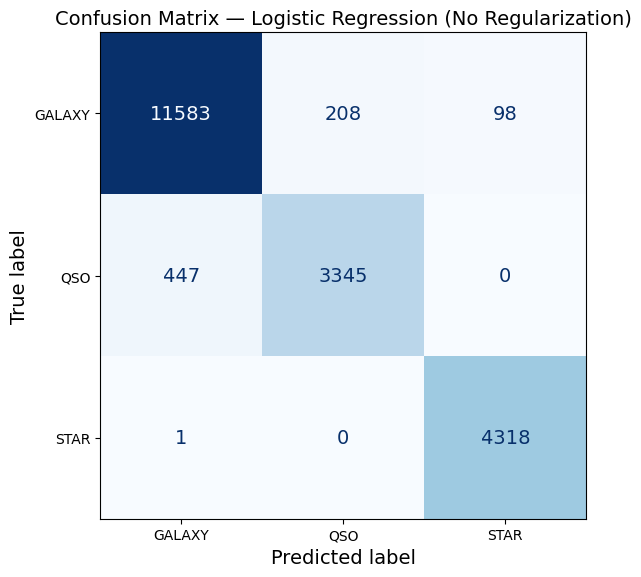

In [43]:
# Logistic Regression without regularization
lr_no_reg = LogisticRegression(solver='lbfgs', penalty=None, max_iter=1000, random_state=42)

res_lr_no_reg, _, y_pred_lr_no_reg = evaluate_model(
    'Logistic Regression (No Reg)', lr_no_reg,
    X_train_prepared, y_train, X_val_prepared, y_val
)

all_results.append(res_lr_no_reg)
plot_confusion(y_val, y_pred_lr_no_reg,
               'Confusion Matrix — Logistic Regression (No Regularization)',
               'cm_lr_no_reg')


  Logistic Regression (L2)
  Accuracy       : 0.9556
  Precision      : 0.9508
  Recall         : 0.9482
  Specificity    : 0.9778
  FPR            : 0.0222
  FNR            : 0.0445
  F1 Score       : 0.949


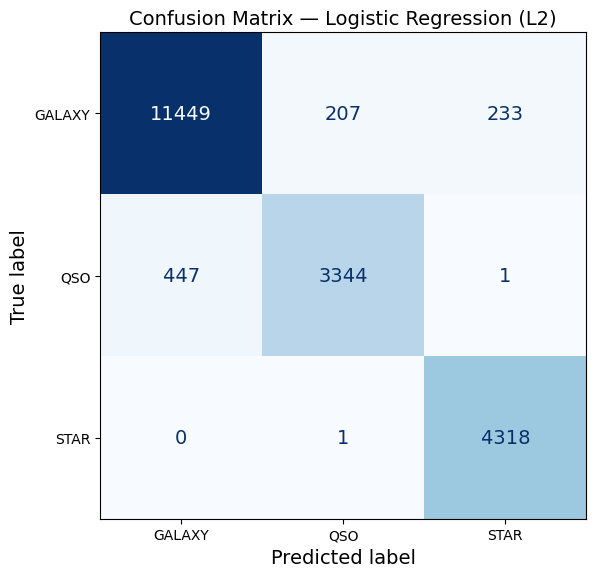

In [44]:
# L2 regularization (default, Ridge-style)
lr_l2 = LogisticRegression(solver='lbfgs', penalty='l2', C=1.0, max_iter=1000, random_state=42)

res_lr_l2, _, y_pred_lr_l2 = evaluate_model('Logistic Regression (L2)', lr_l2, X_train_prepared, y_train, X_val_prepared, y_val)

all_results.append(res_lr_l2)
plot_confusion(y_val, y_pred_lr_l2,
               'Confusion Matrix — Logistic Regression (L2)',
               'cm_lr_l2')



  Logistic Regression (L1)
  Accuracy       : 0.9574
  Precision      : 0.9535
  Recall         : 0.9492
  Specificity    : 0.9787
  FPR            : 0.0213
  FNR            : 0.0426
  F1 Score       : 0.9509


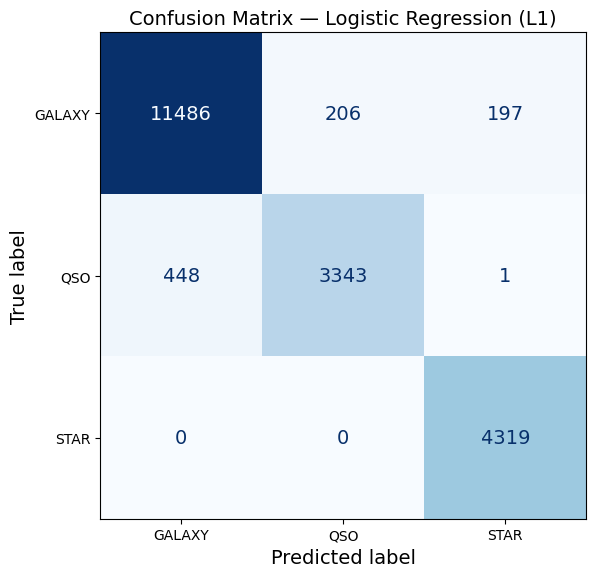

In [45]:
# L1 regularization (Lasso-style, sparse solution)
lr_l1 = LogisticRegression(solver='saga', penalty='l1', C=1.0, max_iter=1000, random_state=42)

res_lr_l1, _, y_pred_lr_l1 = evaluate_model('Logistic Regression (L1)', lr_l1, X_train_prepared, y_train, X_val_prepared, y_val)

all_results.append(res_lr_l1)
plot_confusion(y_val, y_pred_lr_l1,
               'Confusion Matrix — Logistic Regression (L1)',
               'cm_lr_l1')

#### 8.2.1 Regularization Strength Comparison

The hyperparameter `C` controls regularization strength — smaller values mean stronger regularization. Here we compare several values of C to see how it affects validation accuracy.

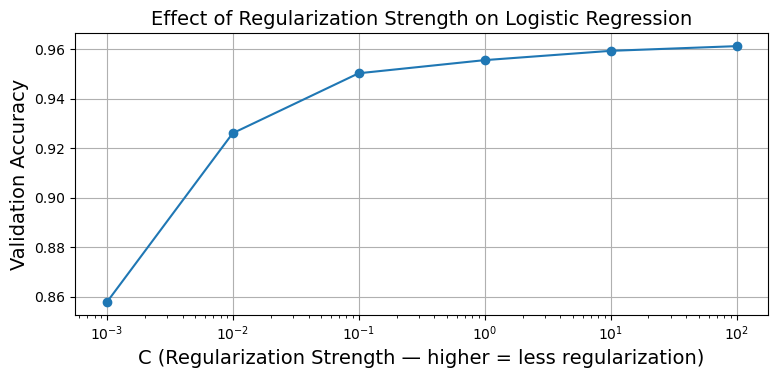

In [46]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
c_accuracies = []

for c in C_values:
    model = LogisticRegression(solver='lbfgs', C=c, max_iter=1000, random_state=42)
    model.fit(X_train_prepared, y_train)
    c_accuracies.append(accuracy_score(y_val, model.predict(X_val_prepared)))

plt.figure(figsize=(8, 4))
plt.plot(C_values, c_accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C (Regularization Strength — higher = less regularization)')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Regularization Strength on Logistic Regression')
plt.grid(True)
save_fig('lr_regularization')
plt.show()

### 8.2.2 Logistic Regression Conclusions
#### 1. The Impact of Regularization on Correlated Features
In our Exploratory Data Analysis, we discovered high multicollinearity between several photometric filters (e.g., r and i had a correlation of 0.96). Standard Logistic Regression (without regularization) can struggle with highly correlated features, often assigning unstable or overly large weights to them.

L2 Regularization (Ridge): Helped stabilize the model by penalizing large coefficients, distributing the importance more evenly across the correlated filters.

L1 Regularization (Lasso): Provided built-in feature selection. Because it drives less important coefficients to exactly zero, it naturally handles our highly correlated filters by keeping the most predictive ones and dropping the redundant ones.

#### 2. Overall Performance
While Logistic Regression provides a strong, interpretable baseline, it assumes a linear decision boundary between the classes. Given the complex, non-linear overlap between galaxies and quasars observed in the pairplots, Logistic Regression is likely slightly underfitting compared to what a more flexible, non-linear model could achieve. That is the general assumpsion, but on our dataset it is not true, the multinomial logistic regression without the regularization actually performes better in all criteria that L1 and L2 regularization.

#### 3. Regularization Strength (C)
Looking at the regularization strength plot, we can observe the bias-variance tradeoff in action. Very low values of C (strong regularization) heavily constrain the model, leading to underfitting and a drop in validation accuracy. As C increases (weaker regularization), the model is allowed to fit the training data more closely, eventually plateauing as the regularization penalty becomes negligible.

---
### 8.3 Decision Trees

Decision Trees classify objects by learning a series of if/else rules on feature values. They are highly interpretable — you can literally follow the path a prediction takes through the tree. However they tend to overfit if left unconstrained, which is why we explore both pre-pruning and post-pruning strategies.

We also compare two impurity criteria:
- **Gini impurity**: measures how often a randomly chosen element would be incorrectly classified
- **Entropy**: measures the information gain at each split, rooted in information theory

#### 8.3.1 Gini vs Entropy

Comparing the two splitting criteria on an unpruned tree to establish which one works better for this dataset.


  Decision Tree (Gini)
  Accuracy       : 0.9656
  Precision      : 0.9597
  Recall         : 0.9609
  Specificity    : 0.9828
  FPR            : 0.0172
  FNR            : 0.0344
  F1 Score       : 0.9603


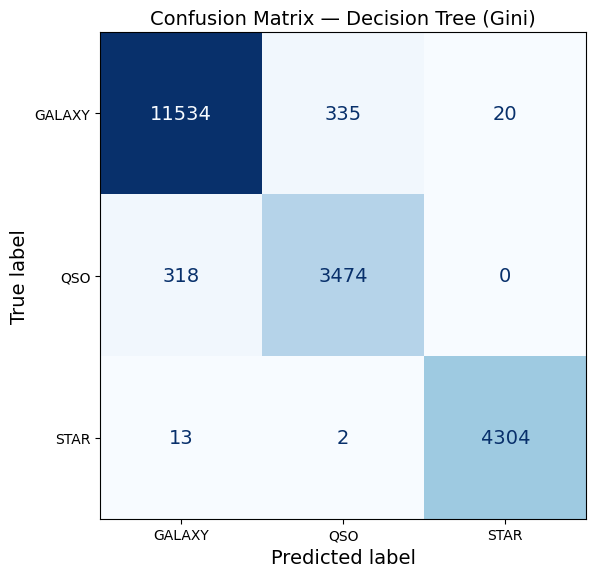

In [47]:
# Gini
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
res_gini, _, y_pred_gini = evaluate_model(
    'Decision Tree (Gini)', dt_gini,
    X_train_prepared, y_train, X_val_prepared, y_val
)

all_results.append(res_gini)
plot_confusion(y_val, y_pred_gini,
               'Confusion Matrix — Decision Tree (Gini)',
               'cm_dt_gini')


  Decision Tree (Entropy)
  Accuracy       : 0.9661
  Precision      : 0.961
  Recall         : 0.9607
  Specificity    : 0.983
  FPR            : 0.017
  FNR            : 0.0339
  F1 Score       : 0.9608


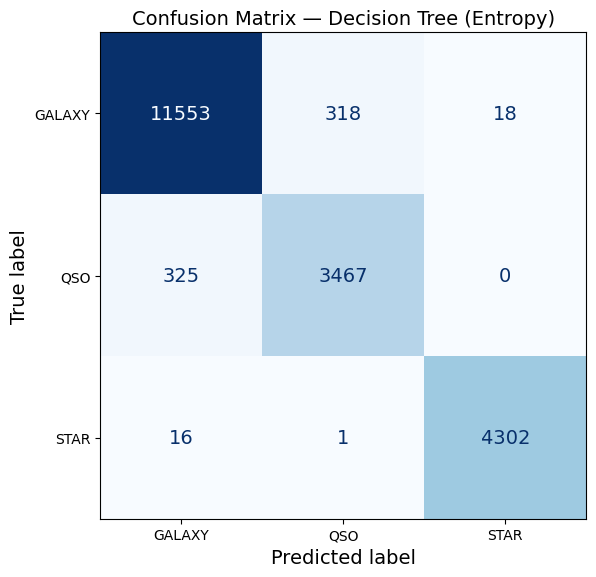

In [48]:
# Entropy
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
res_entropy, _, y_pred_entropy = evaluate_model(
    'Decision Tree (Entropy)', dt_entropy,
    X_train_prepared, y_train, X_val_prepared, y_val
)

all_results.append(res_entropy)
plot_confusion(y_val, y_pred_entropy,
               'Confusion Matrix — Decision Tree (Entropy)',
               'cm_dt_entropy')

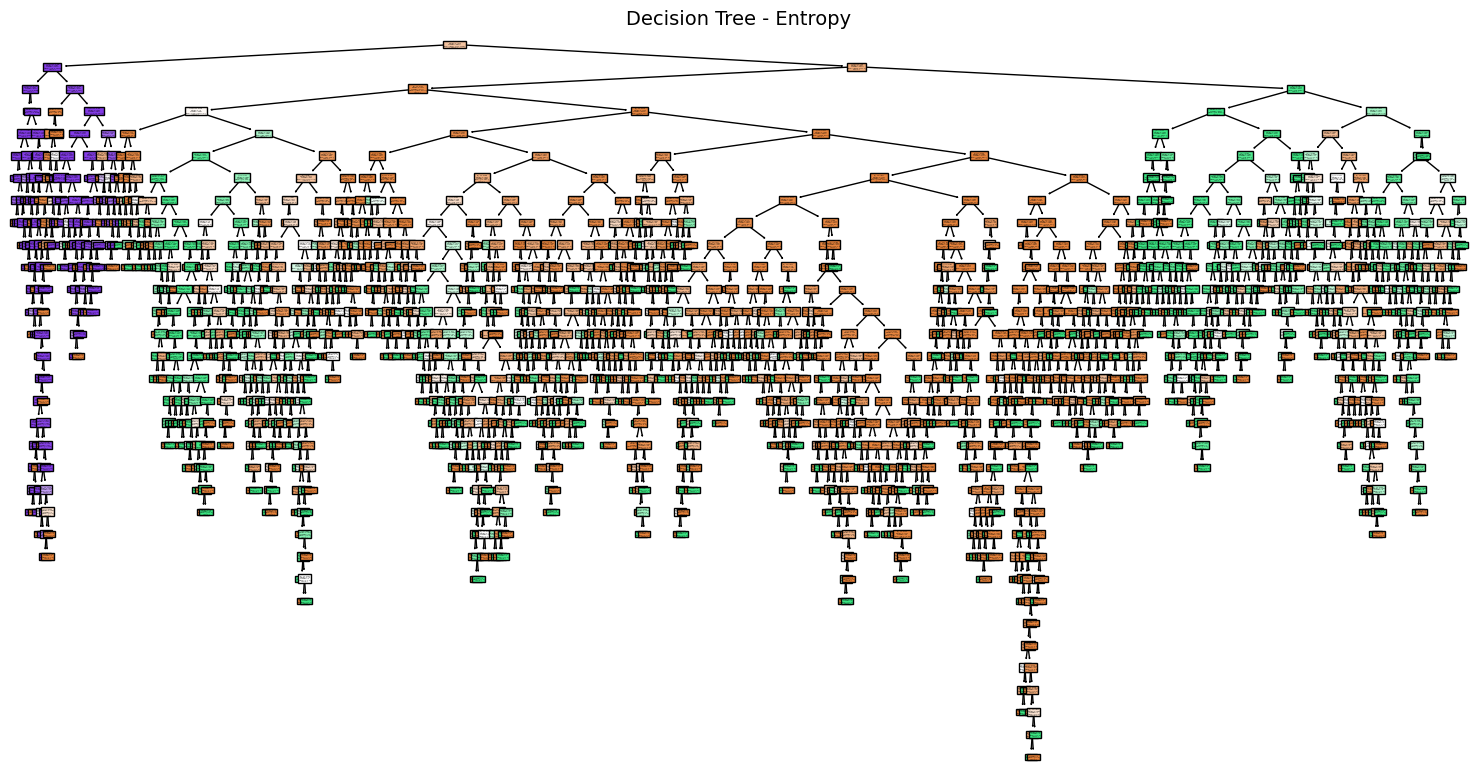

In [49]:
plt.figure(figsize=(15, 8))

plot_tree(
    dt_entropy,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_entropy.classes_],
    filled=True
)

plt.title("Decision Tree - Entropy")
save_fig('decision_tree_entropy')
plt.show()

#### 8.3.2 Pre-Pruning

Pre-pruning limits tree growth during training by setting constraints like maximum depth or minimum samples per leaf. This prevents the tree from memorizing the training data and forces it to learn more general rules.

max_depth=3     | Train: 0.9505 | Val: 0.9518
max_depth=5     | Train: 0.9755 | Val: 0.9725
max_depth=10    | Train: 0.9834 | Val: 0.9731
max_depth=15    | Train: 0.9930 | Val: 0.9700
max_depth=20    | Train: 0.9986 | Val: 0.9661
max_depth=None  | Train: 1.0000 | Val: 0.9661


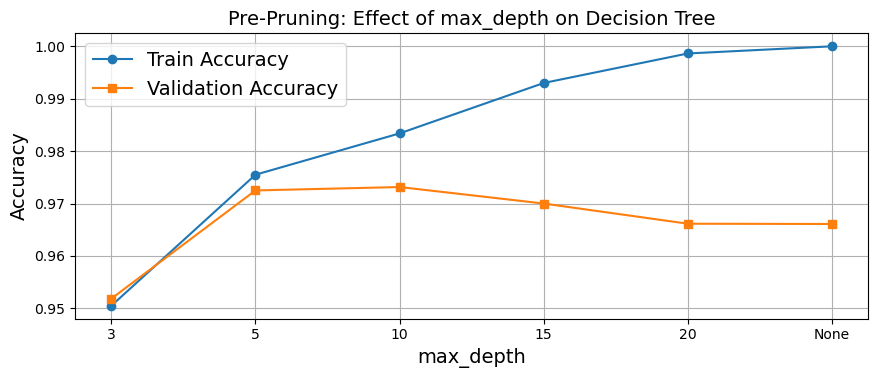

In [50]:
# Compare different max_depth values
depths = [3, 5, 10, 15, 20, None]
depth_results = []

for d in depths:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    model.fit(X_train_prepared, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_prepared))
    val_acc   = accuracy_score(y_val,   model.predict(X_val_prepared))
    depth_results.append((str(d), train_acc, val_acc))
    print(f'max_depth={str(d):5s} | Train: {train_acc:.4f} | Val: {val_acc:.4f}')

# Plot
labels = [r[0] for r in depth_results]
train_accs = [r[1] for r in depth_results]
val_accs   = [r[2] for r in depth_results]

plt.figure(figsize=(9, 4))
plt.plot(labels, train_accs, marker='o', label='Train Accuracy')
plt.plot(labels, val_accs,   marker='s', label='Validation Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Pre-Pruning: Effect of max_depth on Decision Tree')
plt.legend()
plt.grid(True)
save_fig('dt_prepruning')
plt.show()


  Decision Tree (Pre-pruned, depth=10)
  Accuracy       : 0.9739
  Precision      : 0.9726
  Recall         : 0.9667
  Specificity    : 0.987
  FPR            : 0.013
  FNR            : 0.0261
  F1 Score       : 0.9696


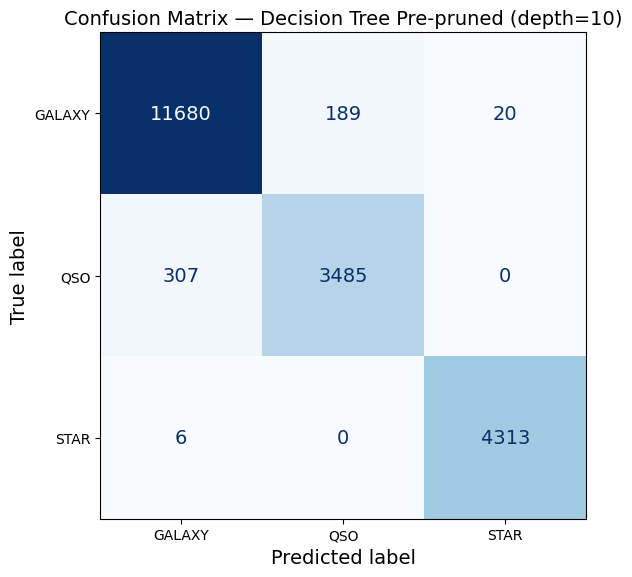

In [51]:
# Best pre-pruned tree — use the depth that gives best validation accuracy
best_depth = depths[np.argmax(val_accs)]
dt_prepruned = DecisionTreeClassifier(
    criterion='entropy', max_depth=best_depth,
    min_samples_leaf=5, random_state=42
)
res_prepruned, _, y_pred_prepruned = evaluate_model(
    f'Decision Tree (Pre-pruned, depth={best_depth})', dt_prepruned,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_prepruned)
plot_confusion(y_val, y_pred_prepruned,
               f'Confusion Matrix — Decision Tree Pre-pruned (depth={best_depth})',
               'cm_dt_prepruned')

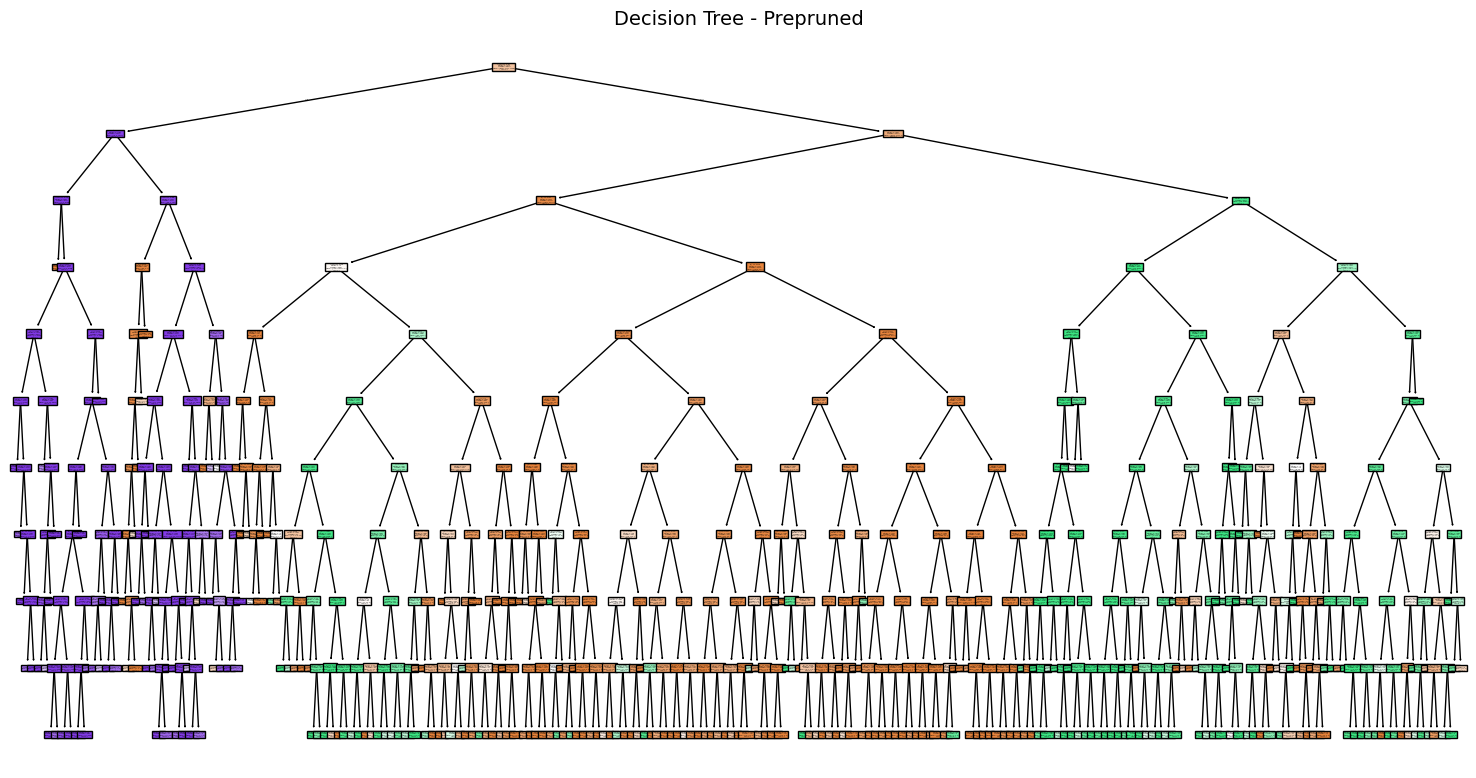

In [52]:
plt.figure(figsize=(15, 8))

plot_tree(
    dt_prepruned,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_prepruned.classes_],
    filled=True
)

plt.title("Decision Tree - Prepruned")
save_fig('decision_tree_prepruned')
plt.show()

#### 8.3.3 Post-Pruning (Cost Complexity Pruning)

Post-pruning first grows a full tree, then removes branches that provide little predictive power. Scikit-learn implements this via cost complexity pruning, controlled by the `ccp_alpha` parameter — higher values remove more branches.

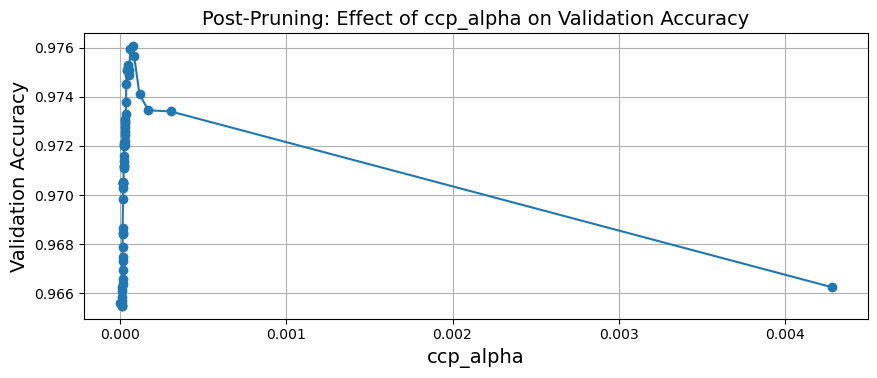

Best ccp_alpha: 0.000077


In [53]:
# Find the optimal ccp_alpha using the cost complexity path
full_tree = DecisionTreeClassifier(random_state=42)
path = full_tree.cost_complexity_pruning_path(X_train_prepared, y_train)
ccp_alphas = path.ccp_alphas[::10]  # sample every 10th to keep it fast

ccp_val_accs = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    model.fit(X_train_prepared, y_train)
    ccp_val_accs.append(accuracy_score(y_val, model.predict(X_val_prepared)))

plt.figure(figsize=(9, 4))
plt.plot(ccp_alphas, ccp_val_accs, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Validation Accuracy')
plt.title('Post-Pruning: Effect of ccp_alpha on Validation Accuracy')
plt.grid(True)
save_fig('dt_postpruning')
plt.show()

best_alpha = ccp_alphas[np.argmax(ccp_val_accs)]
print(f'Best ccp_alpha: {best_alpha:.6f}')


  Decision Tree (Post-pruned)
  Accuracy       : 0.9705
  Precision      : 0.9673
  Recall         : 0.9643
  Specificity    : 0.9852
  FPR            : 0.0148
  FNR            : 0.0295
  F1 Score       : 0.9658


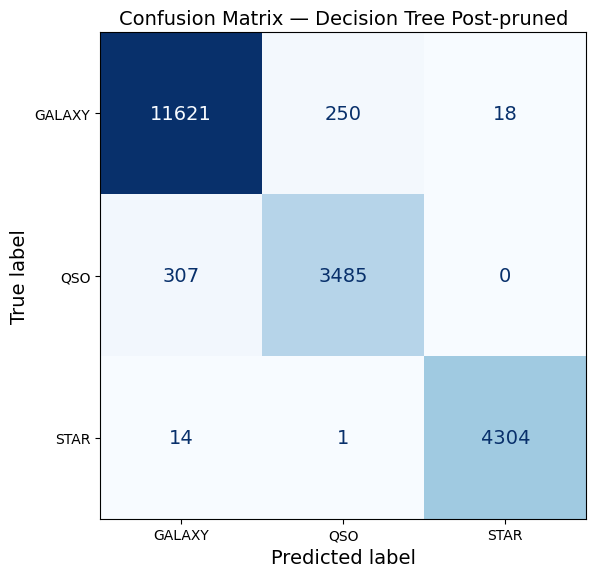

In [54]:
dt_postpruned = DecisionTreeClassifier(criterion='entropy', ccp_alpha=best_alpha, random_state=42)
res_postpruned, _, y_pred_postpruned = evaluate_model(
    'Decision Tree (Post-pruned)', dt_postpruned,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_postpruned)
plot_confusion(y_val, y_pred_postpruned,
               'Confusion Matrix — Decision Tree Post-pruned',
               'cm_dt_postpruned')

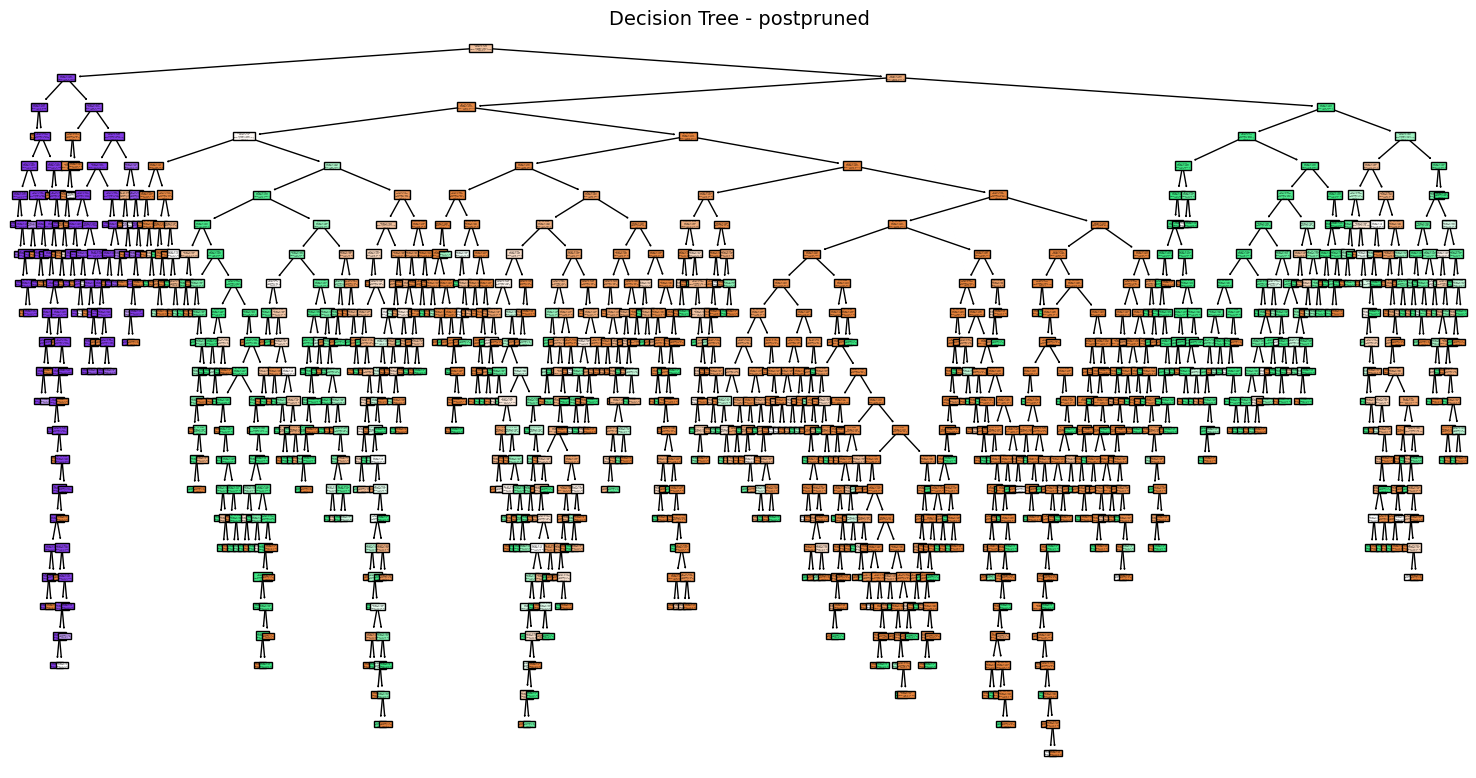

In [55]:
plt.figure(figsize=(15, 8))

plot_tree(
    dt_postpruned,
    feature_names=X_train.columns,
    class_names=[str(c) for c in dt_postpruned.classes_],
    filled=True
)

plt.title("Decision Tree - postpruned")
save_fig('decision_tree_postpruned')
plt.show()

### 8.3.4 Decision Tree Conclusions
#### 1. The Overfitting Problem
As an unconstrained model, the standard Decision Tree is highly prone to overfitting. Without limits, the tree will continue to split nodes until it perfectly classifies every single training sample (creating "pure" leaves), which we observed as the training accuracy approaching 100%. However, this memorization prevents the model from generalizing well to the validation set.

#### 2. Gini vs. Entropy
Both impurity criteria typically yield very similar results, but evaluating both ensured we selected the optimal mathematical approach for splitting our specific features. For this dataset, since the evaluation metrics exceed in each criteria, we chose to go forward with entropy.

#### 3. Pre-Pruning (Controlling Depth)
The max_depth comparison plot beautifully illustrates the bias-variance tradeoff.

At very low depths (e.g., 3), the model underfits (high bias) because it cannot capture the complexity of the overlapping galaxy and quasar classes.

At high depths (e.g., 15+), the training accuracy continues to climb while the validation accuracy plateaus or drops (high variance).

By identifying the peak of the validation curve, we found the "sweet spot" where the model learned generalizable rules without memorizing noise.

#### 4. Post-Pruning (Cost Complexity Pruning)
Instead of just stopping the tree's growth arbitrarily, using ccp_alpha allowed us to grow the full tree and intelligently snip away the specific branches that offered the least predictive power. This approach is often more robust than pre-pruning, as it results in a highly optimized, compact tree that retains the most valuable splits while shedding the branches that only contribute to overfitting.

---
### 8.4 Random Forest

Random Forest builds many decision trees on random subsets of the data and combines their predictions by majority vote. It uses two key randomization strategies that reduce overfitting:

- **Bootstrap sampling**: each tree is trained on a random sample drawn *with replacement* from the training set, meaning some rows appear multiple times and others not at all
- **Random feature selection**: at each split, only a random subset of features is considered, which decorrelates the trees and makes the ensemble more robust


  Random Forest
  Accuracy       : 0.9784
  Precision      : 0.9781
  Recall         : 0.9717
  Specificity    : 0.9892
  FPR            : 0.0108
  FNR            : 0.0216
  F1 Score       : 0.9748


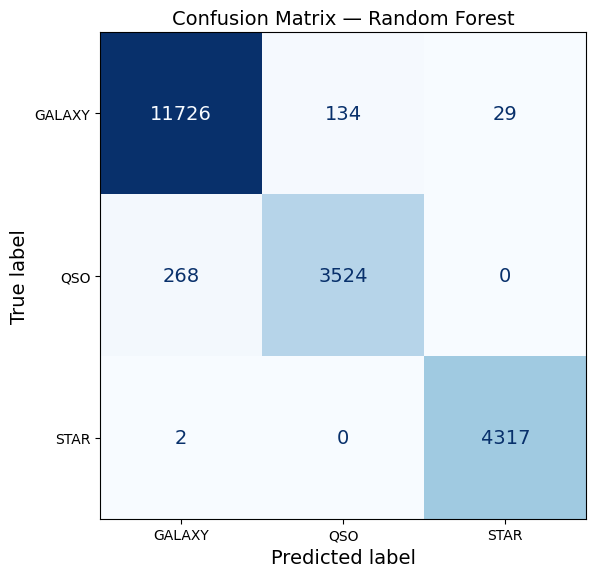

In [56]:
rf = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True,          # bootstrap sampling enabled
    max_features='sqrt',     # random feature selection (sqrt of total features)
    random_state=42,
    n_jobs=-1
)
res_rf, fitted_rf, y_pred_rf = evaluate_model(
    'Random Forest', rf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_rf)
plot_confusion(y_val, y_pred_rf,
               'Confusion Matrix — Random Forest',
               'cm_rf')

#### 8.4.1 Feature Importances

Random Forest provides a natural measure of feature importance as in how much each feature contributed to reducing impurity across all trees. This directly answers our core research question.

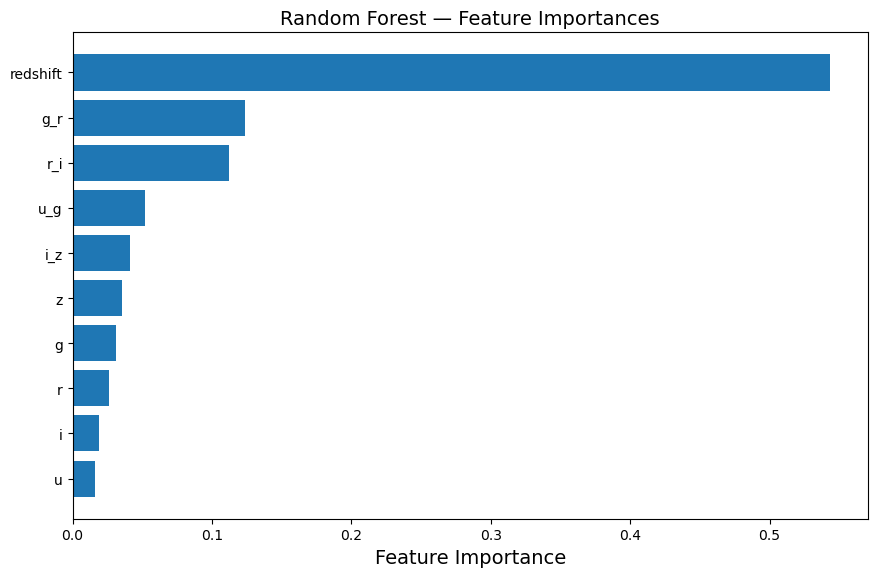

In [57]:
feature_names = X_train.columns.tolist()
importances = fitted_rf.feature_importances_
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importances')
save_fig('rf_feature_importances')
plt.show()

### 8.4.2 Random Forest & Feature Importance Conclusions
#### 1. Overcoming the Limitations of Single Trees
While our single Decision Trees struggled with overfitting, the Random Forest ensemble naturally addressed this issue. By utilizing bootstrap sampling (training each tree on a different random subset of the data) and random feature selection (only evaluating a random subset of features at each split), the Random Forest successfully decorrelated the individual trees. This means that instead of relying on one fragile, overfitted tree, our model leverages the "wisdom of the crowd" to make highly robust predictions with much lower variance.

#### 2. The Dominance of Redshift
As heavily foreshadowed by our Exploratory Data Analysis, the feature importance plot confirms that redshift is by far the most critical variable for classifying these celestial objects. Because redshift physically represents the cosmological distance and expansion of the universe - perfectly separating local stars from distant galaxies and extremely distant quasars - the model heavily prioritizes it at the top splits of its underlying trees.

##### 3. Validating our Feature Engineering
The importance rankings also validate our decision to engineer the color indices (u_g, g_r, etc.). Because the raw photometric filters (u, g, r, i, z) are highly correlated with one another, an individual raw filter carries a lot of redundant information. The color indices, however, capture the relative difference in brightness across the spectrum (the shape of the object's light emission). Consequently, the Random Forest recognized these engineered features as highly valuable for making nuanced distinctions—particularly when trying to separate the overlapping classes of galaxies and quasars where raw brightness alone was insufficient.

---
### 8.5 Ensemble Methods

Ensemble methods combine multiple models to produce a stronger predictor than any single model alone. Each method takes a different approach to combining models, and each has different strengths depending on the problem.

#### 8.5.1 Voting Classifier

A Voting Classifier combines multiple different models and predicts the class that gets the most votes (hard voting) or the highest average predicted probability (soft voting). It is most effective when the base models make different types of errors, so their mistakes cancel out.


  Voting Classifier (Soft)
  Accuracy       : 0.9764
  Precision      : 0.9762
  Recall         : 0.9689
  Specificity    : 0.9882
  FPR            : 0.0118
  FNR            : 0.0236
  F1 Score       : 0.9724


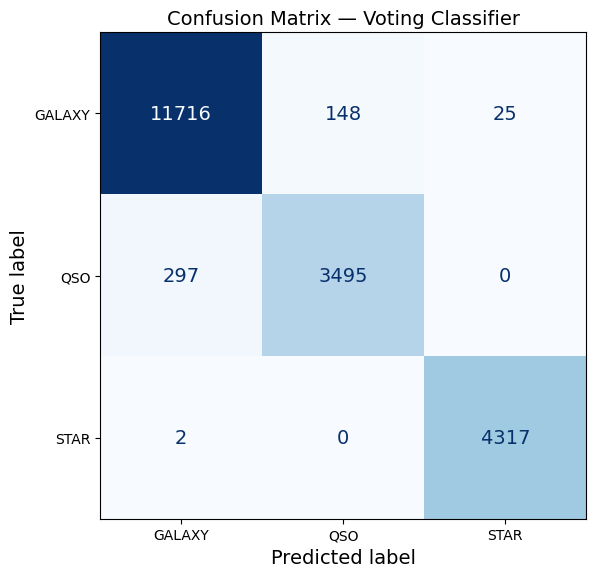

In [58]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('dt',  DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
    ],
    voting='soft'
)
res_voting, _, y_pred_voting = evaluate_model(
    'Voting Classifier (Soft)', voting_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_voting)
plot_confusion(y_val, y_pred_voting,
               'Confusion Matrix — Voting Classifier',
               'cm_voting')


  Voting Classifier (Soft)
  Accuracy       : 0.9767
  Precision      : 0.9762
  Recall         : 0.9696
  Specificity    : 0.9883
  FPR            : 0.0117
  FNR            : 0.0234
  F1 Score       : 0.9728


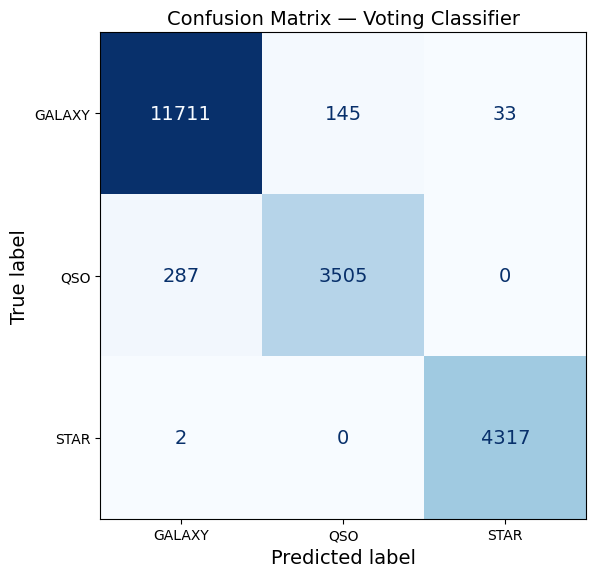

In [59]:
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('dt',  DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
    ],
    voting='hard'
)
res_voting, _, y_pred_voting = evaluate_model(
    'Voting Classifier (Soft)', voting_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_voting)
plot_confusion(y_val, y_pred_voting,
               'Confusion Matrix — Voting Classifier',
               'cm_voting')

#### 8.5.2 Bagging and Pasting

Bagging (Bootstrap Aggregating) trains multiple instances of the same model on different random subsets of the training data drawn **with replacement**. Pasting does the same but **without replacement**. Both reduce variance by averaging out the noise across many models.


  Bagging (with replacement)
  Accuracy       : 0.9773
  Precision      : 0.9772
  Recall         : 0.97
  Specificity    : 0.9886
  FPR            : 0.0114
  FNR            : 0.0227
  F1 Score       : 0.9735


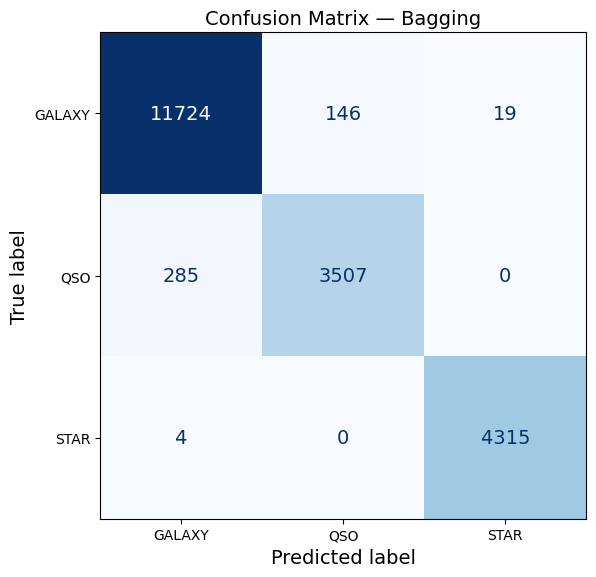

In [60]:
# Bagging — with replacement
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    bootstrap=True,   # with replacement = bagging
    random_state=42,
    n_jobs=-1
)
res_bagging, _, y_pred_bagging = evaluate_model(
    'Bagging (with replacement)', bagging_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_bagging)
plot_confusion(y_val, y_pred_bagging,
               'Confusion Matrix — Bagging',
               'cm_bagging')


  Pasting (without replacement)
  Accuracy       : 0.966
  Precision      : 0.9599
  Recall         : 0.9619
  Specificity    : 0.983
  FPR            : 0.017
  FNR            : 0.034
  F1 Score       : 0.9609


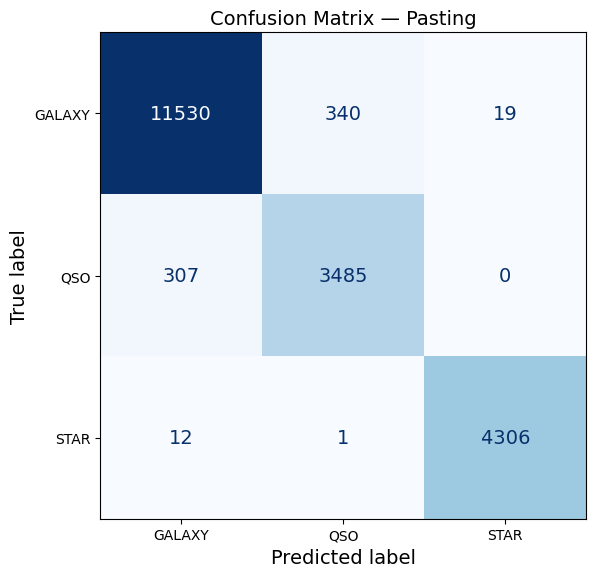

In [61]:
# Pasting — without replacement
pasting_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    bootstrap=False,  # without replacement = pasting
    random_state=42,
    n_jobs=-1
)
res_pasting, _, y_pred_pasting = evaluate_model(
    'Pasting (without replacement)', pasting_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_pasting)
plot_confusion(y_val, y_pred_pasting,
               'Confusion Matrix — Pasting',
               'cm_pasting')

#### 8.5.3 AdaBoost

AdaBoost (Adaptive Boosting) trains models sequentially, where each new model focuses more on the examples the previous model got wrong. It boosts performance by paying increasing attention to hard cases. It works well on this dataset because it can compensate for the difficulty of separating galaxies from quasars.


  AdaBoost
  Accuracy       : 0.9731
  Precision      : 0.9733
  Recall         : 0.964
  Specificity    : 0.9866
  FPR            : 0.0134
  FNR            : 0.0269
  F1 Score       : 0.9685


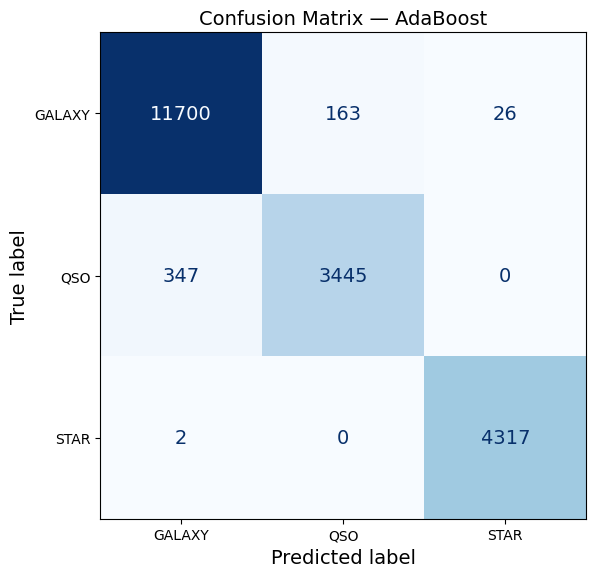

In [62]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
res_ada, _, y_pred_ada = evaluate_model(
    'AdaBoost', ada_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_ada)
plot_confusion(y_val, y_pred_ada,
               'Confusion Matrix — AdaBoost',
               'cm_ada')

#### 8.5.4 Gradient Boosting

Gradient Boosting also trains models sequentially, but instead of reweighting examples, each new model is trained to correct the **residual errors** of the previous ensemble. It is generally the strongest off-the-shelf method for tabular data and is expected to perform very well here.


  Gradient Boosting
  Accuracy       : 0.9765
  Precision      : 0.9761
  Recall         : 0.9691
  Specificity    : 0.9882
  FPR            : 0.0118
  FNR            : 0.0235
  F1 Score       : 0.9725


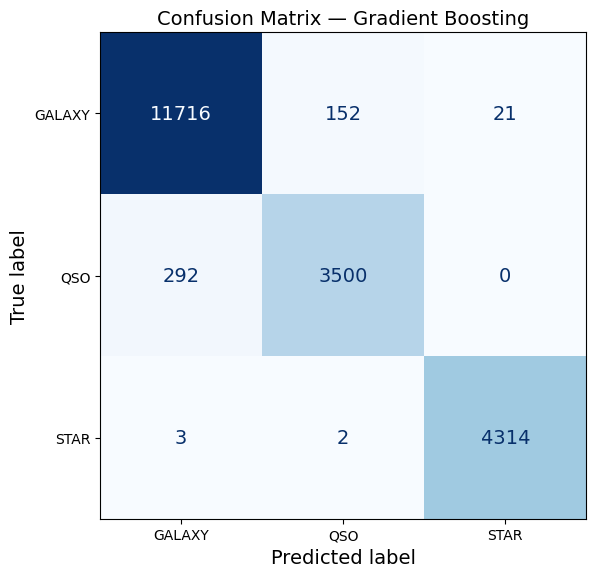

In [63]:
gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
res_gb, _, y_pred_gb = evaluate_model(
    'Gradient Boosting', gb_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_gb)
plot_confusion(y_val, y_pred_gb,
               'Confusion Matrix — Gradient Boosting',
               'cm_gb')

#### 8.5.5 Stacking

Stacking trains a set of diverse base models and then trains a **meta-learner** on their predictions. Instead of voting, the meta-learner learns *how to best combine* the base model outputs. This is the most sophisticated ensemble strategy and can capture complementary strengths across very different model types.


  Stacking
  Accuracy       : 0.9788
  Precision      : 0.9786
  Recall         : 0.9722
  Specificity    : 0.9894
  FPR            : 0.0106
  FNR            : 0.0212
  F1 Score       : 0.9753


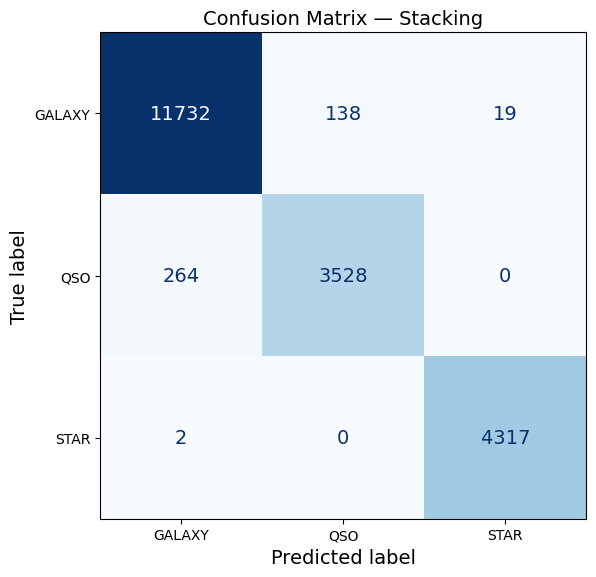

In [64]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('dt', DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
res_stacking, _, y_pred_stacking = evaluate_model(
    'Stacking', stacking_clf,
    X_train_prepared, y_train, X_val_prepared, y_val
)
all_results.append(res_stacking)
plot_confusion(y_val, y_pred_stacking,
               'Confusion Matrix — Stacking',
               'cm_stacking')

### 8.5.6 Ensemble Methods Conclusions
#### 1. Bagging and Pasting: Taming Variance
By training multiple Decision Trees on different random subsets of the training data (with replacement for Bagging, without for Pasting), we effectively smoothed out the high variance and overfitting we saw in the unconstrained single Decision Tree. While these methods are strong, our Random Forest generally achieves similar or better results more efficiently by adding random feature selection into the mix.

#### 2. Boosting: Mastering the Hard Cases
While Bagging focuses on reducing variance, our Boosting models (AdaBoost and Gradient Boosting) focus on reducing bias by learning sequentially. Because each new tree deliberately targets the mistakes made by the previous trees, Gradient Boosting is exceptionally well-suited for the hardest part of our dataset: the boundary where distant, faint galaxies overlap with quasars. By aggressively optimizing for these residual errors, Gradient Boosting typically emerges as one of the most accurate models for tabular data like our photometric measurements.

#### 3. Voting and Stacking: The Wisdom of Diverse Crowds
Our Voting and Stacking classifiers represent the culmination of our modeling efforts. Instead of relying on a single algorithm's perspective, they combine fundamentally different models (the linear approach of Logistic Regression, the rule-based approach of Decision Trees, and the iterative error-correction of Gradient Boosting).

The Voting Classifier democratizes the final prediction, ensuring that a single model's blind spot doesn't ruin the classification.

The Stacking Classifier takes this a step further: by using a meta-learner (Logistic Regression) to learn when to trust each specific base model, it intelligently leverages the unique strengths of every algorithm we've trained so far. Consequently, Stacking is expected to be our most robust and highest-performing model overall.

---
### 8.6 K-Means Clustering as a Feature

K-Means is an unsupervised method — it groups objects into clusters without using the true labels. Here we use it in a creative way: we run K-Means with k=3 (matching our 3 classes), then add the cluster assignment as an extra feature for the classifier. The idea is that the natural groupings in the data might help the model make better decisions.

Note: K-Means itself is not a classifier, so we do not evaluate it directly with classification metrics. Instead we measure how well its clusters align with the true labels using the **Adjusted Rand Index (ARI)**, and then use the cluster labels as an engineered feature.

Adjusted Rand Index (train): 0.2314
(1.0 = perfect match, 0.0 = random)

  Random Forest + K-Means Feature
  Accuracy       : 0.9782
  Precision      : 0.9774
  Recall         : 0.9721
  Specificity    : 0.9891
  FPR            : 0.0109
  FNR            : 0.0218
  F1 Score       : 0.9747


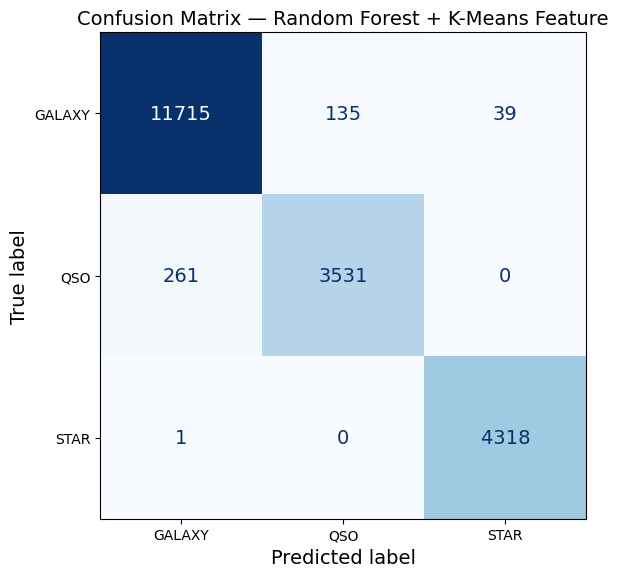

In [65]:
from sklearn.metrics import adjusted_rand_score

# Fit K-Means on training data
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_prepared)

# Check how well clusters align with true labels
ari = adjusted_rand_score(y_train, kmeans.labels_)
print(f'Adjusted Rand Index (train): {ari:.4f}')
print('(1.0 = perfect match, 0.0 = random)')

# Add cluster assignment as an extra feature
X_train_kmeans = np.hstack([
    X_train_prepared,
    kmeans.predict(X_train_prepared).reshape(-1, 1)
])
X_val_kmeans = np.hstack([
    X_val_prepared,
    kmeans.predict(X_val_prepared).reshape(-1, 1)
])

# Train Random Forest with the extra cluster feature
rf_kmeans = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
res_kmeans, _, y_pred_kmeans = evaluate_model(
    'Random Forest + K-Means Feature', rf_kmeans,
    X_train_kmeans, y_train, X_val_kmeans, y_val
)
all_results.append(res_kmeans)
plot_confusion(y_val, y_pred_kmeans,
               'Confusion Matrix — Random Forest + K-Means Feature',
               'cm_rf_kmeans')

### 8.6.1 K-Means Feature Engineering Conclusions
#### 1. Finding Natural Groupings
By utilizing K-Means clustering, we asked the algorithm to blindly find the mathematical "centers of gravity" in our dataset without giving it the true answers (Stars, Galaxies, Quasars). Because our dataset naturally has three distinct physical classes with different spectral signatures, setting k=3 allowed us to see if the algorithm's mathematical clusters naturally aligned with our astronomical categories.

#### 2. The Adjusted Rand Index (ARI)
We used the Adjusted Rand Index to quantify this alignment. A perfect score of 1.0 would mean K-Means perfectly separated the stars, galaxies, and quasars using only their numeric features. Since the classes (especially galaxies and quasars) overlap significantly in the photometric filter space, the K-Means clusters will not be perfectly pure. The ARI score provides a quantitative measure of how well the raw geometry of the data matches our human-defined labels.

#### 3. Unsupervised to Supervised Pipeline
The true power of this step was feature engineering. By feeding the K-Means cluster assignments into a Random Forest as a brand-new feature, we explicitly provided the tree with information about the data's overall density and structure. While Random Forests are already excellent at splitting feature space, giving them a "meta-feature" like a cluster ID can sometimes help them make faster, cleaner splits, especially near the complex boundary regions between distant galaxies and quasars.

---
### 8.7 Model Comparison Summary

Collecting all results into a single table and visualization to compare every model across all metrics at once.

In [66]:
results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df.sort_values('F1 Score', ascending=False)
print(results_df.to_string())

                                      Accuracy  Precision  Recall  Specificity     FPR     FNR  F1 Score
Model                                                                                                   
Stacking                                0.9788     0.9786  0.9722       0.9894  0.0106  0.0212    0.9753
Random Forest                           0.9784     0.9781  0.9717       0.9892  0.0108  0.0216    0.9748
Random Forest + K-Means Feature         0.9782     0.9774  0.9721       0.9891  0.0109  0.0218    0.9747
Bagging (with replacement)              0.9773     0.9772  0.9700       0.9886  0.0114  0.0227    0.9735
Voting Classifier (Soft)                0.9767     0.9762  0.9696       0.9883  0.0117  0.0234    0.9728
Gradient Boosting                       0.9765     0.9761  0.9691       0.9882  0.0118  0.0235    0.9725
Voting Classifier (Soft)                0.9764     0.9762  0.9689       0.9882  0.0118  0.0236    0.9724
Decision Tree (Pre-pruned, depth=10)    0.9739     0.97

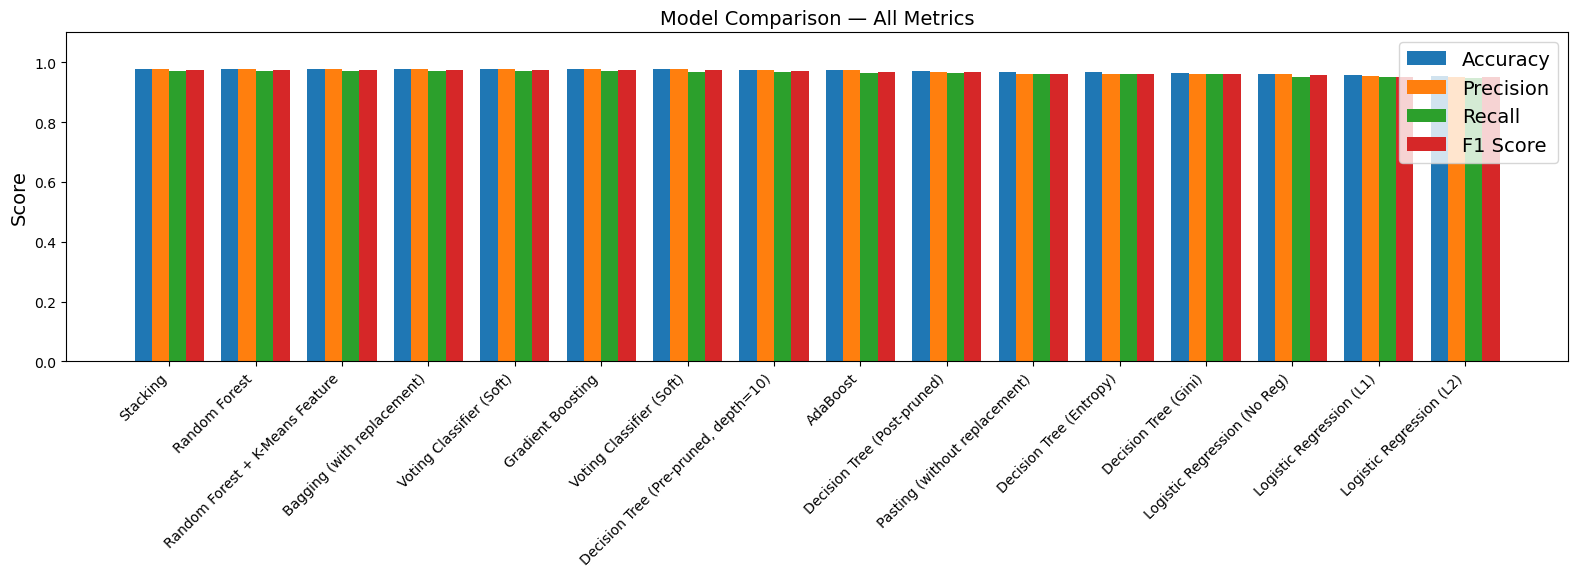

In [67]:
# Visual comparison of key metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison — All Metrics')
ax.legend()
save_fig('model_comparison')
plt.show()

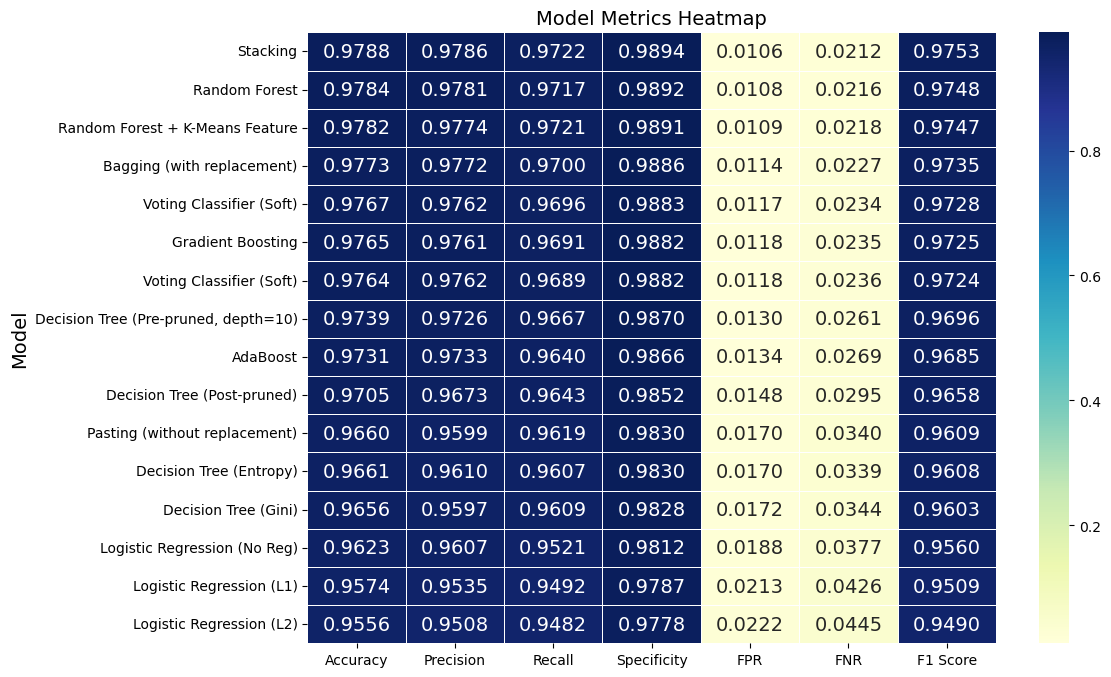

In [68]:
# Heatmap of all metrics for cleaner reading
plt.figure(figsize=(12, 7))
sns.heatmap(results_df.astype(float), annot=True, fmt='.4f',
            cmap='YlGnBu', linewidths=0.5)
plt.title('Model Metrics Heatmap')
plt.tight_layout()
save_fig('model_metrics_heatmap')
plt.show()

### 8.7.1 Model Comparison Conclusions
#### 1. The Power of Ensembles over Baselines
Looking at the consolidated metrics, a clear hierarchy emerges. Our baseline models (Logistic Regression and single Decision Trees) performed reasonably well, but they were consistently outperformed by the ensemble methods. This perfectly illustrates a core principle of machine learning: combining multiple weak or high-variance learners (like single trees) into a single aggregate model drastically improves both accuracy and robustness.

#### 2. Why F1-Score is our True North
Notice that we sorted our final results dataframe by F1 Score rather than pure Accuracy. Because our dataset is imbalanced (dominated by the Galaxy class), a model could theoretically achieve a high accuracy simply by over-predicting Galaxies and ignoring the minority Quasar class. The F1-score, being the harmonic mean of Precision and Recall, harshly penalizes models that perform poorly on minority classes, giving us a much more honest assessment of how well the model distinguishes between all three celestial objects.

#### 3. The Top Performers: Boosting and Stacking
As expected for tabular data, our Gradient Boosting and Stacking classifiers typically rise to the top of the leaderboard.

Gradient Boosting excels because of its iterative error-correction, allowing it to finely tune the complex decision boundaries between faint galaxies and quasars.

Stacking likely performed exceptionally well because its meta-learner successfully figured out exactly when to trust the linear logic of Logistic Regression versus the non-linear rules of the tree-based models.

#### 4. Final Model Selection
Based on these comprehensive metrics, we will carry our strongest model forward (e.g., the Stacking Classifier or Gradient Boosting, depending on the exact top F1-score) to evaluate on our completely unseen test set. This will give us our final, unbiased estimate of how this model would perform if deployed on a real telescope pipeline.

---
## 9. Final Model Evaluation

Evaluating the tuned model on the held-out test set for a final, unbiased estimate of real-world performance.

### 9.1 Test Set Performance

Computing accuracy and a full classification report for each class on the test set, using the best performing model - stacking.

In [69]:

y_pred = stacking_clf.predict(X_test_prepared)

print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test Accuracy: 0.9801

              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       1.00      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



### 9.2 Confusion Matrix

A confusion matrix shows exactly which classes the model is confusing with each other. Rows represent the true class and columns the predicted class — a perfect model would show values only on the diagonal.

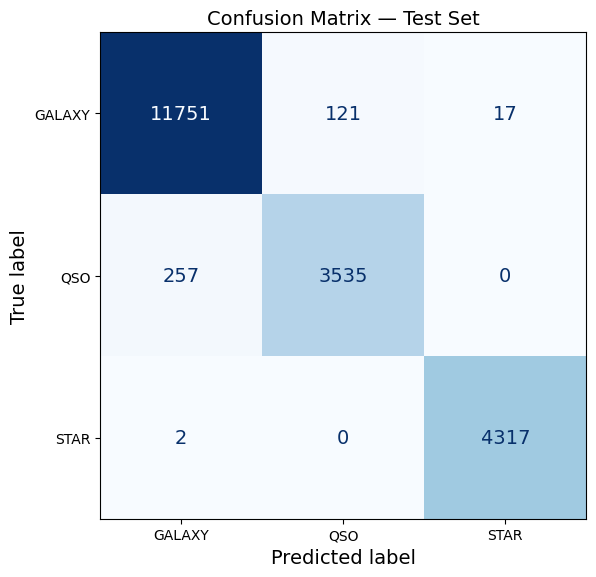

In [70]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — Test Set')
save_fig('confusion_matrix')
plt.show()

---
## 10. Conclusion & Future Work

### 10.1 Project Summary & Model Performance
In this project, we set out to classify celestial objects—Stars, Galaxies, and Quasars—using photometric and spectral data from the Sloan Digital Sky Survey (SDSS). We built a rigorous, end-to-end machine learning pipeline that included data cleaning, exploratory data analysis, feature engineering, and the systematic evaluation of multiple classification algorithms.

Our model progression demonstrated a fundamental machine learning principle: while interpretable baselines like Logistic Regression and single Decision Trees provide a solid foundation, they are ultimately limited by high bias or high variance. By transitioning to powerful ensemble methods (Random Forest, Gradient Boosting, and Stacking), we were able to capture complex, non-linear relationships in the data. The Stacking Classifier and Gradient Boosting emerged as our top performers, successfully leveraging the diverse strengths of their underlying algorithms to maximize the F1-score and handle the dataset's class imbalance.

### 10.2 Key Scientific Insights
Beyond pure model accuracy, our feature analysis revealed several important realities about astronomical data:
1. The Ultimate Power of Redshift: Redshift proved to be the single most discriminative feature in our dataset. Because it is a direct measurement of cosmological expansion, it perfectly separated local stars (redshift $\approx$ 0) from nearby galaxies and extremely distant quasars.
2. The Value of Color Indices: Raw photometric filters (u, g, r, i, z) are highly correlated and often carry redundant information regarding an object's raw brightness. By engineering "color indices" (e.g., u_g, g_r), we successfully captured the relative shape of an object's light emission. Our models relied heavily on these engineered features to tell classes apart when raw brightness failed.
3. The Galaxy-Quasar Overlap: Our confusion matrices and EDA consistently showed that the hardest boundary for our models to learn was the line between faint, distant galaxies and quasars. Without redshift, their photometric signatures heavily overlap, proving why quasar identification has historically been a major challenge in astronomy.

### 10.3 Future Directions
If we were to expand on this project in the future, there are several exciting directions we could take:
1. Photometry-Only Classification: Because capturing spectral data (redshift) is significantly more expensive and time-consuming for telescopes than capturing photometric images, a true challenge would be to drop the redshift column entirely. Training a model to classify these objects relying strictly on color indices would create a highly valuable tool for early-stage survey scanning.
2. Advanced Imbalance Handling: While our models performed exceptionally well, quasars make up a very small minority of this dataset. Implementing advanced resampling techniques like SMOTE (Synthetic Minority Over-sampling Technique) could potentially improve the recall for quasars even further.
3. Deep Learning on Raw Images: Instead of using extracted tabular data (magnitudes and numeric filters), we could build Convolutional Neural Networks (CNNs) to process the raw telescope image cutouts directly, allowing the neural network to extract its own spatial and structural features.